<a href="https://colab.research.google.com/github/Watchman77/solar-flare-multihorizon/blob/main/3H_FINAL_FIXED_FAST_SAFE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 3H Final Fixed Notebook — Fast, Resumable, Journal-Safe

This notebook is designed to **stop the 3h experiment from wasting days**.

What is fixed:
- No duplicate code blocks.
- No moving-average window crash.
- No broken Transformer `Dropout` bug.
- Runs are **checkpointed** after every model, so if Colab disconnects, rerun and it skips completed models.
- Official selection uses **Validation TSS only**.
- Test set is used only for final reporting.
- Bootstrap CI and McNemar are key-aligned.

Default mode is **FAST_FINAL** to close the 3h chapter quickly.  
Change `RUN_MODE = "FULL_TUNING"` only if you really want to run the heavy full grid.


In [1]:
# ============================================================
# 0) MOUNT GOOGLE DRIVE
# ============================================================

from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [2]:
# ============================================================
# 1) SETUP
# ============================================================

import os
import re
import gc
import json
import random
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import tensorflow as tf
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    confusion_matrix,
    roc_auc_score,
    average_precision_score,
    precision_score,
    recall_score,
    f1_score
)
from sklearn.linear_model import LogisticRegressionCV
from sklearn.model_selection import StratifiedKFold
from scipy.stats import chi2

SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow:", tf.__version__)
print("Seed:", SEED)


TensorFlow: 2.20.0
Seed: 42


In [3]:
# ============================================================
# 2) PATHS + RUN MODE
# ============================================================

BASE = "/content/drive/MyDrive/AR_Stratified/HMI_SHARP_HOURLY"

DATA_PATH = f"{BASE}/HMI_AR_2010_2025_ML_READY_16_LABELED_MX3H_FLARE_FEATURES_HOURLY.csv"

OUT_DIR = f"{BASE}/3H_FINAL_FIXED_FAST_SAFE"
SPLIT_CACHE_DIR = os.path.join(OUT_DIR, "split_cache")
PRED_DIR = os.path.join(OUT_DIR, "predictions")
RESULTS_DIR = os.path.join(OUT_DIR, "results")

for d in [OUT_DIR, SPLIT_CACHE_DIR, PRED_DIR, RESULTS_DIR]:
    os.makedirs(d, exist_ok=True)

# ------------------------------------------------------------
# FAST_FINAL is recommended to close the 3h chapter quickly.
# FULL_TUNING is available but heavy.
# ------------------------------------------------------------
RUN_MODE = "FAST_FINAL"   # "FAST_FINAL" or "FULL_TUNING"

MAX_GAP_HOURS = 2.0
EPOCHS_TUNE = 20
BOOT_N = 2000

# For extreme imbalance. Set to 1.0 if you want pure balanced class weights.
POS_MULTIPLIER = 1.15

print("RUN_MODE:", RUN_MODE)
print("Loading:", DATA_PATH)
print("Saving to:", OUT_DIR)


RUN_MODE: FAST_FINAL
Loading: /content/drive/MyDrive/AR_Stratified/HMI_SHARP_HOURLY/HMI_AR_2010_2025_ML_READY_16_LABELED_MX3H_FLARE_FEATURES_HOURLY.csv
Saving to: /content/drive/MyDrive/AR_Stratified/HMI_SHARP_HOURLY/3H_FINAL_FIXED_FAST_SAFE


In [4]:
# ============================================================
# 3) LOAD DATA
# ============================================================

df = pd.read_csv(DATA_PATH)

df["T_REC_dt"] = pd.to_datetime(df["T_REC_dt"], errors="coerce")
df["NOAA_AR"] = pd.to_numeric(df["NOAA_AR"], errors="coerce").astype("Int64")
df["label_MX_3h"] = pd.to_numeric(df["label_MX_3h"], errors="coerce").fillna(0).astype(int)

MAG_FEATURES = [
    "MEANGBZ", "MEANGAM", "MEANGBT", "MEANGBH", "MEANJZD",
    "TOTUSJZ", "MEANALP", "MEANJZH", "ABSNJZH", "SAVNCPP",
    "MEANSHR", "SHRGT45", "R_VALUE", "USFLUX", "TOTPOT", "TOTUSJH"
]

FLARE_HISTORY_FEATURES = [
    "flare_count_past_3h",
    "time_since_last_flare_hours_3h",
    "max_peak_flux_past_3h",
    "mean_peak_flux_past_3h",
    "flare_activity_index_past_3h",
    "had_flare_past_3h",
]

ALL_FEATURES = MAG_FEATURES + FLARE_HISTORY_FEATURES

needed_cols = ["T_REC_dt", "NOAA_AR", "label_MX_3h"] + ALL_FEATURES
missing_cols = [c for c in needed_cols if c not in df.columns]
if missing_cols:
    raise ValueError(f"Missing columns: {missing_cols}")

# Basic imputation
for col in ALL_FEATURES:
    df[col] = pd.to_numeric(df[col], errors="coerce")
    med = df[col].median()
    if pd.isna(med):
        med = 0.0
    df[col] = df[col].fillna(med)

df = df.dropna(subset=["T_REC_dt", "NOAA_AR"]).copy()
df["NOAA_AR"] = df["NOAA_AR"].astype(int)
df = df.sort_values(["NOAA_AR", "T_REC_dt"]).reset_index(drop=True)

print("Dataset shape:", df.shape)
print("Feature count:", len(ALL_FEATURES))
print(df["label_MX_3h"].value_counts())
print(df["label_MX_3h"].value_counts(normalize=True))

positive_rate = df["label_MX_3h"].mean()
print(f"3h positive rate / random PR-AUC baseline ≈ {positive_rate:.6f}")


Dataset shape: (482189, 27)
Feature count: 22
label_MX_3h
0    479138
1      3051
Name: count, dtype: int64
label_MX_3h
0    0.993673
1    0.006327
Name: proportion, dtype: float64
3h positive rate / random PR-AUC baseline ≈ 0.006327


In [5]:
# ============================================================
# 4) MODEL CANDIDATES
# ============================================================

if RUN_MODE == "FAST_FINAL":
    # This is the rescue mode. It runs a small but fair set:
    # all four model families, lookbacks 4 and 8.
    # Lookback 4 is included because previous partial runs showed strong 3h TSS.
    LOOKBACK_GRID = [4, 8]

    LSTM_CANDIDATES = [
        {"units": 64,  "dense_units": 32, "dropout": 0.2, "lr": 1e-3, "batch_size": 256},
        {"units": 128, "dense_units": 32, "dropout": 0.2, "lr": 5e-4, "batch_size": 128},
    ]

    BILSTM_CANDIDATES = [
        {"units": 128, "dense_units": 32, "dropout": 0.2, "lr": 5e-4, "batch_size": 128},
        {"units": 128, "dense_units": 32, "dropout": 0.2, "lr": 1e-3, "batch_size": 128},
        {"units": 64,  "dense_units": 32, "dropout": 0.3, "lr": 1e-3, "batch_size": 128},
    ]

    DLSTM_CANDIDATES = [
        {"ma_window": 3, "units": 64,  "dropout": 0.2, "lr": 1e-3, "batch_size": 256},
        {"ma_window": 3, "units": 128, "dropout": 0.2, "lr": 1e-3, "batch_size": 128},
    ]

    TRANSFORMER_CANDIDATES = [
        {"num_blocks": 1, "num_heads": 2, "key_dim": 16, "ff_dim": 64, "dropout": 0.2, "lr": 1e-3, "batch_size": 256},
        {"num_blocks": 1, "num_heads": 4, "key_dim": 16, "ff_dim": 64, "dropout": 0.2, "lr": 5e-4, "batch_size": 256},
    ]

else:
    # Heavy mode. Use only when you have time.
    LOOKBACK_GRID = [4, 8, 12]

    LSTM_CANDIDATES = [
        {"units": u, "dense_units": 32, "dropout": d, "lr": lr, "batch_size": bs}
        for u in [64, 128] for d in [0.2, 0.3] for lr in [1e-3, 5e-4] for bs in [128, 256]
    ]

    BILSTM_CANDIDATES = [
        {"units": u, "dense_units": 32, "dropout": d, "lr": lr, "batch_size": bs}
        for u in [64, 128] for d in [0.2, 0.3] for lr in [1e-3, 5e-4] for bs in [128, 256]
    ]

    DLSTM_CANDIDATES = [
        {"ma_window": ma, "units": u, "dropout": d, "lr": lr, "batch_size": bs}
        for ma in [3, 5] for u in [64, 128] for d in [0.2, 0.3] for lr in [1e-3, 5e-4] for bs in [128, 256]
    ]

    TRANSFORMER_CANDIDATES = [
        {"num_blocks": b, "num_heads": h, "key_dim": 16, "ff_dim": 64, "dropout": d, "lr": lr, "batch_size": bs}
        for b in [1, 2] for h in [2, 4] for d in [0.2, 0.3] for lr in [1e-3, 5e-4] for bs in [128, 256]
    ]

print("Lookbacks:", LOOKBACK_GRID)
print("Candidates per lookback:",
      "LSTM", len(LSTM_CANDIDATES),
      "BiLSTM", len(BILSTM_CANDIDATES),
      "DLSTM", len(DLSTM_CANDIDATES),
      "Transformer", len(TRANSFORMER_CANDIDATES))


Lookbacks: [4, 8]
Candidates per lookback: LSTM 2 BiLSTM 3 DLSTM 2 Transformer 2


In [6]:
# ============================================================
# 5) METRIC HELPERS
# ============================================================

def tss_hss_from_cm(cm):
    tn, fp, fn, tp = cm.ravel()

    recall = tp / (tp + fn + 1e-9)
    fpr = fp / (fp + tn + 1e-9)
    tss = recall - fpr

    numerator = 2 * (tp * tn - fp * fn)
    denominator = ((tp + fn) * (fn + tn) + (tp + fp) * (fp + tn) + 1e-9)
    hss = numerator / denominator

    return float(tss), float(hss)


def tune_threshold_by_tss(y_true, prob):
    thresholds = np.linspace(0, 1, 1001)
    best_thr = 0.5
    best_tss = -999.0

    for thr in thresholds:
        y_pred = (prob >= thr).astype(int)
        cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
        tss, _ = tss_hss_from_cm(cm)

        if tss > best_tss:
            best_tss = tss
            best_thr = thr

    return float(best_thr), float(best_tss)


def evaluate_probs(model_name, y_val, val_prob, y_test, test_prob, extra=None):
    threshold, val_tss = tune_threshold_by_tss(y_val, val_prob)

    y_pred = (test_prob >= threshold).astype(int)
    cm = confusion_matrix(y_test, y_pred, labels=[0, 1])
    tss, hss = tss_hss_from_cm(cm)
    tn, fp, fn, tp = cm.ravel()

    result = {
        "Model": model_name,
        "Threshold": threshold,
        "Val_TSS": val_tss,
        "Test_TSS": tss,
        "HSS": hss,
        "ROC_AUC": float(roc_auc_score(y_test, test_prob)),
        "PR_AUC": float(average_precision_score(y_test, test_prob)),
        "Recall": float(recall_score(y_test, y_pred, zero_division=0)),
        "Precision": float(precision_score(y_test, y_pred, zero_division=0)),
        "F1": float(f1_score(y_test, y_pred, zero_division=0)),
        "TN": int(tn),
        "FP": int(fp),
        "FN": int(fn),
        "TP": int(tp),
    }

    if extra:
        result.update(extra)

    return result, y_pred


def get_class_weights(y, pos_multiplier=1.0):
    classes = np.unique(y)
    weights = compute_class_weight(class_weight="balanced", classes=classes, y=y)
    out = {int(c): float(w) for c, w in zip(classes, weights)}

    if 1 in out:
        out[1] *= float(pos_multiplier)

    return out


def mcnemar_test(y_true, pred_a, pred_b):
    y_true = np.asarray(y_true).astype(int)
    pred_a = np.asarray(pred_a).astype(int)
    pred_b = np.asarray(pred_b).astype(int)

    correct_a = pred_a == y_true
    correct_b = pred_b == y_true

    b = int(np.sum(correct_a & ~correct_b))
    c = int(np.sum(~correct_a & correct_b))
    n = b + c

    if n == 0:
        chi2_stat = 0.0
        p_value = 1.0
    else:
        chi2_stat = ((abs(b - c) - 1) ** 2) / (n + 1e-9)
        p_value = float(chi2.sf(chi2_stat, df=1))

    return {"b": b, "c": c, "n": n, "chi2": float(chi2_stat), "p_value": p_value}


def bootstrap_tss_ci(y_true, y_pred, n_boot=2000, seed=42):
    rng = np.random.default_rng(seed)
    y_true = np.asarray(y_true).astype(int)
    y_pred = np.asarray(y_pred).astype(int)

    scores = []
    n = len(y_true)

    for _ in range(n_boot):
        idx = rng.integers(0, n, n)
        if len(np.unique(y_true[idx])) < 2:
            continue

        cm = confusion_matrix(y_true[idx], y_pred[idx], labels=[0, 1])
        tss, _ = tss_hss_from_cm(cm)
        scores.append(tss)

    scores = np.asarray(scores, dtype=float)

    return {
        "mean": float(np.mean(scores)),
        "ci_low": float(np.percentile(scores, 2.5)),
        "ci_high": float(np.percentile(scores, 97.5)),
        "n_boot_valid": int(len(scores)),
    }, scores


In [7]:
# ============================================================
# 6) SEQUENCE + SPLIT + CACHE HELPERS
# ============================================================

def safe_name(text):
    return re.sub(r"[^A-Za-z0-9_.-]+", "_", str(text))


def build_sequences_with_keys(frame, feature_cols, lookback, max_gap_hours=2.0):
    X_seq, y_seq, t_seq, ar_seq = [], [], [], []

    for ar_num, g in frame.groupby("NOAA_AR"):
        g = g.sort_values("T_REC_dt").reset_index(drop=True)

        if len(g) < lookback:
            continue

        vals = g[feature_cols].values.astype(np.float32)
        labels = g["label_MX_3h"].values.astype(int)
        times = pd.to_datetime(g["T_REC_dt"]).values

        for i in range(lookback - 1, len(g)):
            window_times = pd.to_datetime(times[i - lookback + 1:i + 1])
            diffs = pd.Series(window_times).diff().dropna().dt.total_seconds() / 3600.0

            if len(diffs) > 0 and (diffs > max_gap_hours).any():
                continue

            X_seq.append(vals[i - lookback + 1:i + 1])
            y_seq.append(labels[i])
            t_seq.append(pd.Timestamp(times[i]))
            ar_seq.append(int(ar_num))

    X_seq = np.asarray(X_seq, dtype=np.float32)
    y_seq = np.asarray(y_seq, dtype=int)

    keys = pd.DataFrame({
        "NOAA_AR": np.asarray(ar_seq, dtype=int),
        "T_REC_dt": pd.to_datetime(np.asarray(t_seq)),
        "y": y_seq,
    })

    return X_seq, y_seq, keys


def chronological_split_with_keys(X_seq, y_seq, keys_df, train_frac=0.70, val_frac=0.15):
    order = np.argsort(pd.to_datetime(keys_df["T_REC_dt"]).values)

    X_seq = X_seq[order]
    y_seq = y_seq[order]
    keys_df = keys_df.iloc[order].reset_index(drop=True)

    n = len(X_seq)
    n_train = int(train_frac * n)
    n_val = int(val_frac * n)

    return {
        "X_train": X_seq[:n_train],
        "y_train": y_seq[:n_train],
        "keys_train": keys_df.iloc[:n_train].reset_index(drop=True),

        "X_val": X_seq[n_train:n_train+n_val],
        "y_val": y_seq[n_train:n_train+n_val],
        "keys_val": keys_df.iloc[n_train:n_train+n_val].reset_index(drop=True),

        "X_test": X_seq[n_train+n_val:],
        "y_test": y_seq[n_train+n_val:],
        "keys_test": keys_df.iloc[n_train+n_val:].reset_index(drop=True),
    }


def scale_3d_train_only(X_train, X_val, X_test):
    scaler = StandardScaler()
    n_features = X_train.shape[-1]

    X_train_scaled = scaler.fit_transform(
        X_train.reshape(-1, n_features)
    ).reshape(X_train.shape)

    X_val_scaled = scaler.transform(
        X_val.reshape(-1, n_features)
    ).reshape(X_val.shape)

    X_test_scaled = scaler.transform(
        X_test.reshape(-1, n_features)
    ).reshape(X_test.shape)

    return X_train_scaled.astype(np.float32), X_val_scaled.astype(np.float32), X_test_scaled.astype(np.float32)


def build_or_load_split(lookback):
    npz_path = os.path.join(SPLIT_CACHE_DIR, f"split_lb{lookback}.npz")
    val_keys_path = os.path.join(SPLIT_CACHE_DIR, f"keys_val_lb{lookback}.csv")
    test_keys_path = os.path.join(SPLIT_CACHE_DIR, f"keys_test_lb{lookback}.csv")

    if os.path.exists(npz_path) and os.path.exists(val_keys_path) and os.path.exists(test_keys_path):
        print(f"Loading cached split for lookback={lookback}")
        data = np.load(npz_path, allow_pickle=False)
        return {
            "X_train_scaled": data["X_train_scaled"],
            "y_train": data["y_train"],
            "X_val_scaled": data["X_val_scaled"],
            "y_val": data["y_val"],
            "X_test_scaled": data["X_test_scaled"],
            "y_test": data["y_test"],
            "keys_val": pd.read_csv(val_keys_path, parse_dates=["T_REC_dt"]),
            "keys_test": pd.read_csv(test_keys_path, parse_dates=["T_REC_dt"]),
        }

    print("\n" + "=" * 72)
    print(f"Building sequences for lookback={lookback}")
    print("=" * 72)

    X_seq, y_seq, keys = build_sequences_with_keys(
        df,
        feature_cols=ALL_FEATURES,
        lookback=lookback,
        max_gap_hours=MAX_GAP_HOURS
    )

    split = chronological_split_with_keys(X_seq, y_seq, keys)
    X_train_sc, X_val_sc, X_test_sc = scale_3d_train_only(
        split["X_train"], split["X_val"], split["X_test"]
    )

    out = {
        "X_train_scaled": X_train_sc,
        "y_train": split["y_train"],
        "X_val_scaled": X_val_sc,
        "y_val": split["y_val"],
        "X_test_scaled": X_test_sc,
        "y_test": split["y_test"],
        "keys_val": split["keys_val"],
        "keys_test": split["keys_test"],
    }

    np.savez_compressed(
        npz_path,
        X_train_scaled=out["X_train_scaled"],
        y_train=out["y_train"],
        X_val_scaled=out["X_val_scaled"],
        y_val=out["y_val"],
        X_test_scaled=out["X_test_scaled"],
        y_test=out["y_test"],
    )

    out["keys_val"].to_csv(val_keys_path, index=False)
    out["keys_test"].to_csv(test_keys_path, index=False)

    print("Saved cached split:", npz_path)
    print("Train:", out["X_train_scaled"].shape, int(out["y_train"].sum()))
    print("Val  :", out["X_val_scaled"].shape, int(out["y_val"].sum()))
    print("Test :", out["X_test_scaled"].shape, int(out["y_test"].sum()))

    return out


def moving_average_decomposition(X, window=3):
    # Fast safe centered moving average over time dimension only.
    seq_len = X.shape[1]
    if window > seq_len:
        raise ValueError(f"MA window {window} cannot exceed lookback/sequence length {seq_len}")

    half = window // 2
    trend = np.empty_like(X, dtype=np.float32)

    for t in range(seq_len):
        start = max(0, t - half)
        end = min(seq_len, t + half + 1)
        trend[:, t, :] = X[:, start:end, :].mean(axis=1)

    residual = X - trend
    return trend.astype(np.float32), residual.astype(np.float32)


In [8]:
# ============================================================
# 7) MODEL BUILDERS
# ============================================================

def make_callbacks(patience=5):
    return [
        EarlyStopping(
            monitor="val_auc",
            mode="max",
            patience=patience,
            restore_best_weights=True,
            verbose=0
        ),
        ReduceLROnPlateau(
            monitor="val_auc",
            mode="max",
            factor=0.5,
            patience=max(2, patience // 2),
            min_lr=1e-6,
            verbose=0
        )
    ]


def build_lstm_model(input_shape, units=64, dense_units=32, dropout=0.2, lr=1e-3):
    model = models.Sequential([
        layers.Input(shape=input_shape),
        layers.LSTM(units, return_sequences=False, dropout=dropout, recurrent_dropout=0.0),
        layers.Dense(dense_units, activation="relu", kernel_regularizer=regularizers.l2(1e-4)),
        layers.Dropout(dropout),
        layers.Dense(1, activation="sigmoid"),
    ])
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
        loss="binary_crossentropy",
        metrics=[tf.keras.metrics.AUC(name="auc")]
    )
    return model


def build_bilstm_model(input_shape, units=64, dense_units=32, dropout=0.2, lr=1e-3):
    model = models.Sequential([
        layers.Input(shape=input_shape),
        layers.Bidirectional(
            layers.LSTM(units, return_sequences=False, dropout=dropout, recurrent_dropout=0.0)
        ),
        layers.Dense(dense_units, activation="relu", kernel_regularizer=regularizers.l2(1e-4)),
        layers.Dropout(dropout),
        layers.Dense(1, activation="sigmoid"),
    ])
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
        loss="binary_crossentropy",
        metrics=[tf.keras.metrics.AUC(name="auc")]
    )
    return model


def build_dlstm_model(input_shape, units=64, dropout=0.2, lr=1e-3):
    second_units = max(16, units // 2)
    model = models.Sequential([
        layers.Input(shape=input_shape),
        layers.LSTM(units, return_sequences=True, dropout=dropout, recurrent_dropout=0.0),
        layers.Dropout(dropout),
        layers.LSTM(second_units, return_sequences=False, dropout=dropout, recurrent_dropout=0.0),
        layers.Dropout(dropout),
        layers.Dense(1, activation="sigmoid"),
    ])
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
        loss="binary_crossentropy",
        metrics=[tf.keras.metrics.AUC(name="auc")]
    )
    return model


def transformer_encoder_block(x, num_heads=2, key_dim=16, ff_dim=64, dropout=0.2):
    attn = layers.MultiHeadAttention(
        num_heads=num_heads,
        key_dim=key_dim,
        dropout=dropout
    )(x, x)

    x = layers.Add()([x, attn])
    x = layers.LayerNormalization(epsilon=1e-6)(x)

    ff = layers.Dense(ff_dim, activation="relu")(x)
    ff = layers.Dropout(dropout)(ff)
    ff = layers.Dense(x.shape[-1])(ff)

    x = layers.Add()([x, ff])
    x = layers.LayerNormalization(epsilon=1e-6)(x)
    return x


def build_transformer_model(
    input_shape,
    num_blocks=1,
    num_heads=2,
    key_dim=16,
    ff_dim=64,
    dense_units=32,
    dropout=0.2,
    lr=1e-3
):
    inp = layers.Input(shape=input_shape)
    x = layers.Dense(64, activation="relu")(inp)

    for _ in range(num_blocks):
        x = transformer_encoder_block(
            x,
            num_heads=num_heads,
            key_dim=key_dim,
            ff_dim=ff_dim,
            dropout=dropout
        )

    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dropout(dropout)(x)
    x = layers.Dense(dense_units, activation="relu", kernel_regularizer=regularizers.l2(1e-4))(x)
    x = layers.Dropout(dropout)(x)

    out = layers.Dense(1, activation="sigmoid")(x)

    model = models.Model(inp, out, name="Transformer_3h")
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
        loss="binary_crossentropy",
        metrics=[tf.keras.metrics.AUC(name="auc")]
    )
    return model


In [9]:
# ============================================================
# 8) TRAIN/EVALUATE ONE MODEL WITH CHECKPOINTING
# ============================================================

def save_prediction_frame(path, keys, y, prob, pred):
    frame = keys.copy()
    frame["y"] = np.asarray(y).astype(int)
    frame["prob"] = np.asarray(prob).astype(float)
    frame["pred"] = np.asarray(pred).astype(int)
    frame.to_csv(path, index=False)


def load_existing_results():
    result_files = [
        os.path.join(RESULTS_DIR, f)
        for f in os.listdir(RESULTS_DIR)
        if f.startswith("result__") and f.endswith(".json")
    ]

    rows = []
    for f in result_files:
        with open(f, "r") as handle:
            rows.append(json.load(handle))

    return rows


def train_evaluate_checkpointed(model_name, family, lookback, split, X_train, X_val, X_test, build_fn, build_kwargs, batch_size, extra):
    safe = safe_name(model_name)

    result_path = os.path.join(RESULTS_DIR, f"result__{safe}.json")
    val_pred_path = os.path.join(PRED_DIR, f"val__{safe}.csv")
    test_pred_path = os.path.join(PRED_DIR, f"test__{safe}.csv")
    error_path = os.path.join(RESULTS_DIR, f"error__{safe}.txt")

    if os.path.exists(result_path) and os.path.exists(val_pred_path) and os.path.exists(test_pred_path):
        print(f"SKIP existing: {model_name}")
        with open(result_path, "r") as handle:
            return json.load(handle)

    tf.keras.backend.clear_session()
    random.seed(SEED)
    np.random.seed(SEED)
    tf.random.set_seed(SEED)

    print("\n" + "=" * 90)
    print("Training:", model_name)
    print("=" * 90)

    try:
        input_shape = (X_train.shape[1], X_train.shape[2])
        model = build_fn(input_shape=input_shape, **build_kwargs)

        class_weight = get_class_weights(split["y_train"], pos_multiplier=POS_MULTIPLIER)

        history = model.fit(
            X_train,
            split["y_train"],
            validation_data=(X_val, split["y_val"]),
            epochs=EPOCHS_TUNE,
            batch_size=batch_size,
            class_weight=class_weight,
            callbacks=make_callbacks(patience=5),
            shuffle=False,
            verbose=1
        )

        val_prob = model.predict(X_val, batch_size=512, verbose=0).ravel()
        test_prob = model.predict(X_test, batch_size=512, verbose=0).ravel()

        result, test_pred = evaluate_probs(
            model_name,
            split["y_val"], val_prob,
            split["y_test"], test_prob,
            extra={
                "Family": family,
                "Lookback": lookback,
                "Epochs_Used": len(history.history["loss"]),
                **extra
            }
        )

        _, val_pred = evaluate_probs(
            model_name + "_val_only",
            split["y_val"], val_prob,
            split["y_val"], val_prob,
            extra={}
        )

        save_prediction_frame(val_pred_path, split["keys_val"], split["y_val"], val_prob, val_pred)
        save_prediction_frame(test_pred_path, split["keys_test"], split["y_test"], test_prob, test_pred)

        with open(result_path, "w") as handle:
            json.dump(result, handle, indent=2)

        print(
            f"Val_TSS={result['Val_TSS']:.4f} | "
            f"Test_TSS={result['Test_TSS']:.4f} | "
            f"PR_AUC={result['PR_AUC']:.4f} | "
            f"Precision={result['Precision']:.4f} | "
            f"F1={result['F1']:.4f}"
        )

        del model
        gc.collect()
        return result

    except Exception as e:
        with open(error_path, "w") as handle:
            handle.write(repr(e))
        print("ERROR in", model_name, ":", repr(e))
        gc.collect()
        return None


In [10]:
# ============================================================
# 9) RUN FAST/CONTROLLED TUNING
# This cell can be rerun safely. Completed models are skipped.
# ============================================================

all_rows = load_existing_results()
completed_models = set([r["Model"] for r in all_rows])
print("Existing completed runs:", len(completed_models))

for lb in LOOKBACK_GRID:
    split = build_or_load_split(lb)

    # LSTM
    for cfg in LSTM_CANDIDATES:
        model_name = f"LSTM_3h_LB{lb}_U{cfg['units']}_D{cfg['dropout']}_LR{cfg['lr']}_BS{cfg['batch_size']}"
        if model_name in completed_models:
            continue

        result = train_evaluate_checkpointed(
            model_name=model_name,
            family="LSTM",
            lookback=lb,
            split=split,
            X_train=split["X_train_scaled"],
            X_val=split["X_val_scaled"],
            X_test=split["X_test_scaled"],
            build_fn=build_lstm_model,
            build_kwargs={
                "units": cfg["units"],
                "dense_units": cfg["dense_units"],
                "dropout": cfg["dropout"],
                "lr": cfg["lr"],
            },
            batch_size=cfg["batch_size"],
            extra={
                "MA_Window": np.nan,
                "Units": cfg["units"],
                "Dense_Units": cfg["dense_units"],
                "Dropout": cfg["dropout"],
                "Learning_Rate": cfg["lr"],
                "Batch_Size": cfg["batch_size"],
                "Transformer_Blocks": np.nan,
                "Transformer_Heads": np.nan,
                "Transformer_Key_Dim": np.nan,
                "Transformer_FF_Dim": np.nan,
            }
        )
        if result is not None:
            all_rows.append(result)
            completed_models.add(model_name)

    # BiLSTM
    for cfg in BILSTM_CANDIDATES:
        model_name = f"BiLSTM_3h_LB{lb}_U{cfg['units']}_D{cfg['dropout']}_LR{cfg['lr']}_BS{cfg['batch_size']}"
        if model_name in completed_models:
            continue

        result = train_evaluate_checkpointed(
            model_name=model_name,
            family="BiLSTM",
            lookback=lb,
            split=split,
            X_train=split["X_train_scaled"],
            X_val=split["X_val_scaled"],
            X_test=split["X_test_scaled"],
            build_fn=build_bilstm_model,
            build_kwargs={
                "units": cfg["units"],
                "dense_units": cfg["dense_units"],
                "dropout": cfg["dropout"],
                "lr": cfg["lr"],
            },
            batch_size=cfg["batch_size"],
            extra={
                "MA_Window": np.nan,
                "Units": cfg["units"],
                "Dense_Units": cfg["dense_units"],
                "Dropout": cfg["dropout"],
                "Learning_Rate": cfg["lr"],
                "Batch_Size": cfg["batch_size"],
                "Transformer_Blocks": np.nan,
                "Transformer_Heads": np.nan,
                "Transformer_Key_Dim": np.nan,
                "Transformer_FF_Dim": np.nan,
            }
        )
        if result is not None:
            all_rows.append(result)
            completed_models.add(model_name)

    # DLSTM
    for cfg in DLSTM_CANDIDATES:
        ma_window = cfg["ma_window"]
        if ma_window > lb:
            print(f"Skipping DLSTM lb={lb}, ma_window={ma_window}: MA window > lookback")
            continue

        model_name = f"DLSTM_3h_LB{lb}_MA{ma_window}_U{cfg['units']}_D{cfg['dropout']}_LR{cfg['lr']}_BS{cfg['batch_size']}"
        if model_name in completed_models:
            continue

        trend_train, res_train = moving_average_decomposition(split["X_train_scaled"], window=ma_window)
        trend_val, res_val = moving_average_decomposition(split["X_val_scaled"], window=ma_window)
        trend_test, res_test = moving_average_decomposition(split["X_test_scaled"], window=ma_window)

        X_train_d = np.concatenate([trend_train, res_train], axis=2)
        X_val_d = np.concatenate([trend_val, res_val], axis=2)
        X_test_d = np.concatenate([trend_test, res_test], axis=2)

        result = train_evaluate_checkpointed(
            model_name=model_name,
            family="DLSTM",
            lookback=lb,
            split=split,
            X_train=X_train_d,
            X_val=X_val_d,
            X_test=X_test_d,
            build_fn=build_dlstm_model,
            build_kwargs={
                "units": cfg["units"],
                "dropout": cfg["dropout"],
                "lr": cfg["lr"],
            },
            batch_size=cfg["batch_size"],
            extra={
                "MA_Window": ma_window,
                "Units": cfg["units"],
                "Dense_Units": np.nan,
                "Dropout": cfg["dropout"],
                "Learning_Rate": cfg["lr"],
                "Batch_Size": cfg["batch_size"],
                "Transformer_Blocks": np.nan,
                "Transformer_Heads": np.nan,
                "Transformer_Key_Dim": np.nan,
                "Transformer_FF_Dim": np.nan,
            }
        )
        if result is not None:
            all_rows.append(result)
            completed_models.add(model_name)

        del trend_train, res_train, trend_val, res_val, trend_test, res_test, X_train_d, X_val_d, X_test_d
        gc.collect()

    # Transformer
    for cfg in TRANSFORMER_CANDIDATES:
        model_name = (
            f"Transformer_3h_LB{lb}_B{cfg['num_blocks']}_H{cfg['num_heads']}"
            f"_K{cfg['key_dim']}_FF{cfg['ff_dim']}_D{cfg['dropout']}_LR{cfg['lr']}_BS{cfg['batch_size']}"
        )
        if model_name in completed_models:
            continue

        result = train_evaluate_checkpointed(
            model_name=model_name,
            family="Transformer",
            lookback=lb,
            split=split,
            X_train=split["X_train_scaled"],
            X_val=split["X_val_scaled"],
            X_test=split["X_test_scaled"],
            build_fn=build_transformer_model,
            build_kwargs={
                "num_blocks": cfg["num_blocks"],
                "num_heads": cfg["num_heads"],
                "key_dim": cfg["key_dim"],
                "ff_dim": cfg["ff_dim"],
                "dense_units": 32,
                "dropout": cfg["dropout"],
                "lr": cfg["lr"],
            },
            batch_size=cfg["batch_size"],
            extra={
                "MA_Window": np.nan,
                "Units": np.nan,
                "Dense_Units": 32,
                "Dropout": cfg["dropout"],
                "Learning_Rate": cfg["lr"],
                "Batch_Size": cfg["batch_size"],
                "Transformer_Blocks": cfg["num_blocks"],
                "Transformer_Heads": cfg["num_heads"],
                "Transformer_Key_Dim": cfg["key_dim"],
                "Transformer_FF_Dim": cfg["ff_dim"],
            }
        )
        if result is not None:
            all_rows.append(result)
            completed_models.add(model_name)

# Collate saved result JSONs again
all_rows = load_existing_results()
tuning_all_df = pd.DataFrame(all_rows)

if len(tuning_all_df) == 0:
    raise RuntimeError("No completed results found. Check error files in RESULTS_DIR.")

tuning_by_val = tuning_all_df.sort_values("Val_TSS", ascending=False).reset_index(drop=True)
tuning_by_test = tuning_all_df.sort_values("Test_TSS", ascending=False).reset_index(drop=True)

tuning_by_val.to_csv(os.path.join(OUT_DIR, "3H_FINAL_FIXED_TUNING_BY_VAL_TSS.csv"), index=False)
tuning_by_test.to_csv(os.path.join(OUT_DIR, "AUDIT_ONLY_3H_FINAL_FIXED_BY_TEST_TSS.csv"), index=False)

print("\nBEST CONFIGURATIONS BY VALIDATION TSS")
display(tuning_by_val.head(20).round(4))

print("\nAUDIT ONLY: TOP CONFIGURATIONS BY TEST TSS")
display(tuning_by_test.head(20).round(4))

official_best_model = tuning_by_val.iloc[0]["Model"]
print("\nOfficial best validation-selected model:", official_best_model)
display(pd.DataFrame([tuning_by_val.iloc[0]]).round(4))


Existing completed runs: 18
Loading cached split for lookback=4
Loading cached split for lookback=8

BEST CONFIGURATIONS BY VALIDATION TSS


,Model,Threshold,Val_TSS,Test_TSS,HSS,ROC_AUC,PR_AUC,Recall,Precision,F1,...,MA_Window,Units,Dense_Units,Dropout,Learning_Rate,Batch_Size,Transformer_Blocks,Transformer_Heads,Transformer_Key_Dim,Transformer_FF_Dim
0,DLSTM_3h_LB8_MA3_U64_D0.2_LR0.001_BS256,0.666,0.7266,0.6997,0.0790,0.9361,0.2115,0.7810,0.0465,0.0878,...,3.0,64.0,NaN,0.2,0.0010,256,NaN,NaN,NaN,NaN
1,BiLSTM_3h_LB8_U128_D0.2_LR0.001_BS128,0.606,0.7257,0.7248,0.0538,0.9348,0.1847,0.8529,0.0327,0.0631,...,NaN,128.0,32.0,0.2,0.0010,128,NaN,NaN,NaN,NaN
2,Transformer_3h_LB8_B1_H2_K16_FF64_D0.2_LR0.001...,0.515,0.7254,0.7085,0.0368,0.9362,0.1994,0.8954,0.0238,0.0463,...,NaN,NaN,32.0,0.2,0.0010,256,1.0,2.0,16.0,64.0
3,LSTM_3h_LB8_U128_D0.2_LR0.0005_BS128,0.657,0.7253,0.7191,0.0611,0.9359,0.1984,0.8301,0.0366,0.0702,...,NaN,128.0,32.0,0.2,0.0005,128,NaN,NaN,NaN,NaN
4,DLSTM_3h_LB8_MA3_U128_D0.2_LR0.001_BS128,0.771,0.7239,0.7028,0.0715,0.9316,0.1983,0.7941,0.0424,0.0804,...,3.0,128.0,NaN,0.2,0.0010,128,NaN,NaN,NaN,NaN
5,BiLSTM_3h_LB4_U128_D0.2_LR0.0005_BS128,0.639,0.7234,0.7031,0.0461,0.9294,0.1914,0.8473,0.0286,0.0553,...,NaN,128.0,32.0,0.2,0.0005,128,NaN,NaN,NaN,NaN
6,BiLSTM_3h_LB4_U128_D0.2_LR0.001_BS128,0.637,0.7227,0.7049,0.0477,0.9305,0.1815,0.8443,0.0294,0.0569,...,NaN,128.0,32.0,0.2,0.0010,128,NaN,NaN,NaN,NaN
7,Transformer_3h_LB8_B1_H4_K16_FF64_D0.2_LR0.000...,0.628,0.7225,0.6910,0.0629,0.9358,0.1827,0.7941,0.0377,0.0719,...,NaN,NaN,32.0,0.2,0.0005,256,1.0,4.0,16.0,64.0
8,Transformer_3h_LB4_B1_H4_K16_FF64_D0.2_LR0.000...,0.676,0.7222,0.6826,0.0395,0.9257,0.1923,0.8473,0.0251,0.0488,...,NaN,NaN,32.0,0.2,0.0005,256,1.0,4.0,16.0,64.0
9,LSTM_3h_LB8_U64_D0.2_LR0.001_BS256,0.684,0.7217,0.7298,0.0624,0.9273,0.1995,0.8399,0.0373,0.0715,...,NaN,64.0,32.0,0.2,0.0010,256,NaN,NaN,NaN,NaN



AUDIT ONLY: TOP CONFIGURATIONS BY TEST TSS


,Model,Threshold,Val_TSS,Test_TSS,HSS,ROC_AUC,PR_AUC,Recall,Precision,F1,...,MA_Window,Units,Dense_Units,Dropout,Learning_Rate,Batch_Size,Transformer_Blocks,Transformer_Heads,Transformer_Key_Dim,Transformer_FF_Dim
0,LSTM_3h_LB8_U64_D0.2_LR0.001_BS256,0.684,0.7217,0.7298,0.0624,0.9273,0.1995,0.8399,0.0373,0.0715,...,NaN,64.0,32.0,0.2,0.0010,256,NaN,NaN,NaN,NaN
1,BiLSTM_3h_LB8_U128_D0.2_LR0.001_BS128,0.606,0.7257,0.7248,0.0538,0.9348,0.1847,0.8529,0.0327,0.0631,...,NaN,128.0,32.0,0.2,0.0010,128,NaN,NaN,NaN,NaN
2,LSTM_3h_LB8_U128_D0.2_LR0.0005_BS128,0.657,0.7253,0.7191,0.0611,0.9359,0.1984,0.8301,0.0366,0.0702,...,NaN,128.0,32.0,0.2,0.0005,128,NaN,NaN,NaN,NaN
3,BiLSTM_3h_LB8_U64_D0.3_LR0.001_BS128,0.717,0.7201,0.7154,0.0680,0.9315,0.1904,0.8137,0.0404,0.0770,...,NaN,64.0,32.0,0.3,0.0010,128,NaN,NaN,NaN,NaN
4,Transformer_3h_LB8_B1_H2_K16_FF64_D0.2_LR0.001...,0.515,0.7254,0.7085,0.0368,0.9362,0.1994,0.8954,0.0238,0.0463,...,NaN,NaN,32.0,0.2,0.0010,256,1.0,2.0,16.0,64.0
5,LSTM_3h_LB4_U64_D0.2_LR0.001_BS256,0.662,0.7088,0.7054,0.0521,0.9275,0.1673,0.8323,0.0318,0.0612,...,NaN,64.0,32.0,0.2,0.0010,256,NaN,NaN,NaN,NaN
6,BiLSTM_3h_LB4_U128_D0.2_LR0.001_BS128,0.637,0.7227,0.7049,0.0477,0.9305,0.1815,0.8443,0.0294,0.0569,...,NaN,128.0,32.0,0.2,0.0010,128,NaN,NaN,NaN,NaN
7,BiLSTM_3h_LB4_U128_D0.2_LR0.0005_BS128,0.639,0.7234,0.7031,0.0461,0.9294,0.1914,0.8473,0.0286,0.0553,...,NaN,128.0,32.0,0.2,0.0005,128,NaN,NaN,NaN,NaN
8,DLSTM_3h_LB8_MA3_U128_D0.2_LR0.001_BS128,0.771,0.7239,0.7028,0.0715,0.9316,0.1983,0.7941,0.0424,0.0804,...,3.0,128.0,NaN,0.2,0.0010,128,NaN,NaN,NaN,NaN
9,BiLSTM_3h_LB8_U128_D0.2_LR0.0005_BS128,0.686,0.7201,0.7008,0.0602,0.9316,0.2007,0.8105,0.0362,0.0693,...,NaN,128.0,32.0,0.2,0.0005,128,NaN,NaN,NaN,NaN



Official best validation-selected model: DLSTM_3h_LB8_MA3_U64_D0.2_LR0.001_BS256


,Model,Threshold,Val_TSS,Test_TSS,HSS,ROC_AUC,PR_AUC,Recall,Precision,F1,...,MA_Window,Units,Dense_Units,Dropout,Learning_Rate,Batch_Size,Transformer_Blocks,Transformer_Heads,Transformer_Key_Dim,Transformer_FF_Dim
0,DLSTM_3h_LB8_MA3_U64_D0.2_LR0.001_BS256,0.666,0.7266,0.6997,0.079,0.9361,0.2115,0.781,0.0465,0.0878,...,3.0,64.0,NaN,0.2,0.001,256,NaN,NaN,NaN,NaN


In [11]:
# ============================================================
# 10) FAMILY WINNERS + MCNEMAR WITH KEY ALIGNMENT
# ============================================================

def read_pred_frame(model_name, split_name):
    safe = safe_name(model_name)
    path = os.path.join(PRED_DIR, f"{split_name}__{safe}.csv")
    return pd.read_csv(path, parse_dates=["T_REC_dt"])


best_family_rows = (
    tuning_by_val
    .sort_values("Val_TSS", ascending=False)
    .groupby("Family", as_index=False)
    .first()
    .sort_values("Val_TSS", ascending=False)
    .reset_index(drop=True)
)

print("Best validation-selected model per family:")
display(best_family_rows[[
    "Family", "Model", "Lookback", "Val_TSS", "Test_TSS",
    "ROC_AUC", "PR_AUC", "Recall", "Precision", "F1"
]].round(4))

official_best_model = tuning_by_val.iloc[0]["Model"]
official_family = tuning_by_val.iloc[0]["Family"]

official_test = read_pred_frame(official_best_model, "test").rename(
    columns={"prob": "prob_official", "pred": "pred_official"}
)

mcnemar_rows = []

for _, row in best_family_rows.iterrows():
    comparator_model = row["Model"]
    comparator_family = row["Family"]

    if comparator_model == official_best_model:
        continue

    comp_test = read_pred_frame(comparator_model, "test").rename(
        columns={"prob": "prob_comp", "pred": "pred_comp"}
    )

    merged = official_test.merge(
        comp_test[["NOAA_AR", "T_REC_dt", "y", "prob_comp", "pred_comp"]],
        on=["NOAA_AR", "T_REC_dt", "y"],
        how="inner"
    )

    if len(merged) == 0:
        print("No overlapping test keys for", comparator_model)
        continue

    out = mcnemar_test(
        merged["y"].values,
        merged["pred_official"].values,
        merged["pred_comp"].values
    )

    out.update({
        "Comparison": f"Tuned Best {official_family} vs Best Tuned {comparator_family}",
        "Official_Best_Model": official_best_model,
        "Comparator_Model": comparator_model,
        "Comparator_Family": comparator_family,
        "Overlap_N": int(len(merged)),
        "Interpretation": "Significant difference" if out["p_value"] < 0.05 else "No significant difference"
    })
    mcnemar_rows.append(out)

mcnemar_df = pd.DataFrame(mcnemar_rows)

if len(mcnemar_df):
    mcnemar_df = mcnemar_df[[
        "Comparison",
        "Official_Best_Model",
        "Comparator_Model",
        "Comparator_Family",
        "Overlap_N",
        "b", "c", "n", "chi2", "p_value", "Interpretation"
    ]]
    display(mcnemar_df.round(6))
    mcnemar_df.to_csv(os.path.join(OUT_DIR, "MCNEMAR_3H_FINAL_FIXED_KEY_ALIGNED.csv"), index=False)
else:
    print("No McNemar comparisons available.")


Best validation-selected model per family:


,Family,Model,Lookback,Val_TSS,Test_TSS,ROC_AUC,PR_AUC,Recall,Precision,F1
0,DLSTM,DLSTM_3h_LB8_MA3_U64_D0.2_LR0.001_BS256,8,0.7266,0.6997,0.9361,0.2115,0.7810,0.0465,0.0878
1,BiLSTM,BiLSTM_3h_LB8_U128_D0.2_LR0.001_BS128,8,0.7257,0.7248,0.9348,0.1847,0.8529,0.0327,0.0631
2,Transformer,Transformer_3h_LB8_B1_H2_K16_FF64_D0.2_LR0.001...,8,0.7254,0.7085,0.9362,0.1994,0.8954,0.0238,0.0463
3,LSTM,LSTM_3h_LB8_U128_D0.2_LR0.0005_BS128,8,0.7253,0.7191,0.9359,0.1984,0.8301,0.0366,0.0702


,Comparison,Official_Best_Model,Comparator_Model,Comparator_Family,Overlap_N,b,c,n,chi2,p_value,Interpretation
0,Tuned Best DLSTM vs Best Tuned BiLSTM,DLSTM_3h_LB8_MA3_U64_D0.2_LR0.001_BS256,BiLSTM_3h_LB8_U128_D0.2_LR0.001_BS128,BiLSTM,64411,3127,315,3442,2295.677223,0.0,Significant difference
1,Tuned Best DLSTM vs Best Tuned Transformer,DLSTM_3h_LB8_MA3_U64_D0.2_LR0.001_BS256,Transformer_3h_LB8_B1_H2_K16_FF64_D0.2_LR0.001...,Transformer,64411,6632,158,6790,6170.799558,0.0,Significant difference
2,Tuned Best DLSTM vs Best Tuned LSTM,DLSTM_3h_LB8_MA3_U64_D0.2_LR0.001_BS256,LSTM_3h_LB8_U128_D0.2_LR0.0005_BS128,LSTM,64411,2042,254,2296,1390.840157,0.0,Significant difference


In [12]:
# ============================================================
# 11) BOOTSTRAP CI FOR OFFICIAL BEST MODEL
# ============================================================

official_best_model = tuning_by_val.iloc[0]["Model"]
official_test = read_pred_frame(official_best_model, "test")

bootstrap_3h_ci, boot_scores = bootstrap_tss_ci(
    official_test["y"].values,
    official_test["pred"].values,
    n_boot=BOOT_N,
    seed=SEED
)

bootstrap_3h_ci["model"] = official_best_model
bootstrap_3h_ci["point_tss"] = float(tuning_by_val.iloc[0]["Test_TSS"])

print("Official tuned 3h model:", official_best_model)
print("Bootstrap TSS CI:", bootstrap_3h_ci)

pd.DataFrame([bootstrap_3h_ci]).to_csv(
    os.path.join(OUT_DIR, "BOOTSTRAP_3H_FINAL_FIXED_BEST_TSS_CI.csv"),
    index=False
)

np.save(
    os.path.join(OUT_DIR, "BOOTSTRAP_3H_FINAL_FIXED_BEST_TSS_SCORES.npy"),
    boot_scores
)


Official tuned 3h model: DLSTM_3h_LB8_MA3_U64_D0.2_LR0.001_BS256
Bootstrap TSS CI: {'mean': 0.6987887496359394, 'ci_low': 0.6526116188540577, 'ci_high': 0.7421132200017929, 'n_boot_valid': 2000, 'model': 'DLSTM_3h_LB8_MA3_U64_D0.2_LR0.001_BS256', 'point_tss': 0.6996853701663841}


In [13]:
# ============================================================
# 12) OPTIONAL FAMILY META-ENSEMBLE WITH KEY ALIGNMENT
# ============================================================

family_models = best_family_rows["Model"].tolist()

val_meta = None
test_meta = None

for model_name in family_models:
    family = tuning_by_val.loc[tuning_by_val["Model"] == model_name, "Family"].iloc[0]

    v = read_pred_frame(model_name, "val")[["NOAA_AR", "T_REC_dt", "y", "prob"]].rename(columns={"prob": f"prob_{family}"})
    t = read_pred_frame(model_name, "test")[["NOAA_AR", "T_REC_dt", "y", "prob"]].rename(columns={"prob": f"prob_{family}"})

    if val_meta is None:
        val_meta = v
        test_meta = t
    else:
        val_meta = val_meta.merge(v, on=["NOAA_AR", "T_REC_dt", "y"], how="inner")
        test_meta = test_meta.merge(t, on=["NOAA_AR", "T_REC_dt", "y"], how="inner")

print("Aligned validation meta:", val_meta.shape)
print("Aligned test meta:", test_meta.shape)

prob_cols = [c for c in val_meta.columns if c.startswith("prob_")]

meta_rows = []

if len(prob_cols) >= 2 and len(val_meta) > 0 and len(test_meta) > 0:
    X_meta_val = val_meta[prob_cols].values
    X_meta_test = test_meta[prob_cols].values
    y_meta_val = val_meta["y"].values.astype(int)
    y_meta_test = test_meta["y"].values.astype(int)

    # Average
    val_avg = X_meta_val.mean(axis=1)
    test_avg = X_meta_test.mean(axis=1)

    avg_result, avg_pred = evaluate_probs(
        "3H_FamilyMeta_Average",
        y_meta_val, val_avg,
        y_meta_test, test_avg,
        extra={"Family": "MetaEnsemble", "Lookback": "key_aligned", "Inputs": ", ".join(prob_cols)}
    )
    meta_rows.append(avg_result)

    # Logistic stacking with CV on aligned validation set
    if y_meta_val.sum() > 10:
        cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
        stacker = LogisticRegressionCV(
            Cs=10,
            cv=cv,
            class_weight="balanced",
            max_iter=3000,
            scoring="roc_auc"
        )
        stacker.fit(X_meta_val, y_meta_val)

        val_stack = stacker.predict_proba(X_meta_val)[:, 1]
        test_stack = stacker.predict_proba(X_meta_test)[:, 1]

        stack_result, stack_pred = evaluate_probs(
            "3H_FamilyMeta_Stacking",
            y_meta_val, val_stack,
            y_meta_test, test_stack,
            extra={"Family": "MetaEnsemble", "Lookback": "key_aligned", "Inputs": ", ".join(prob_cols)}
        )
        meta_rows.append(stack_result)

    meta_df = pd.DataFrame(meta_rows).sort_values("Val_TSS", ascending=False).reset_index(drop=True)
    display(meta_df.round(4))
    meta_df.to_csv(os.path.join(OUT_DIR, "3H_FAMILY_META_ENSEMBLE_KEY_ALIGNED.csv"), index=False)
else:
    print("Meta-ensemble skipped: not enough aligned models/keys.")


Aligned validation meta: (89268, 7)
Aligned test meta: (87907, 7)


,Model,Threshold,Val_TSS,Test_TSS,HSS,ROC_AUC,PR_AUC,Recall,Precision,F1,TN,FP,FN,TP,Family,Lookback,Inputs
0,3H_FamilyMeta_Average,0.569,0.7658,0.7527,0.0510,0.9522,0.2070,0.8497,0.0297,0.0574,79103,8498,46,260,MetaEnsemble,key_aligned,"prob_DLSTM, prob_BiLSTM, prob_Transformer, pro..."
1,3H_FamilyMeta_Stacking,0.405,0.7650,0.7615,0.0527,0.9518,0.2007,0.8562,0.0306,0.0591,79305,8296,44,262,MetaEnsemble,key_aligned,"prob_DLSTM, prob_BiLSTM, prob_Transformer, pro..."


In [14]:
# ============================================================
# 13) MANUSCRIPT-READY OUTPUTS
# ============================================================

family_winners_display = best_family_rows[[
    "Family", "Model", "Lookback", "Threshold", "Val_TSS", "Test_TSS",
    "HSS", "ROC_AUC", "PR_AUC", "Recall", "Precision", "F1",
    "TN", "FP", "FN", "TP"
]].copy()

family_winners_display = family_winners_display.sort_values("Val_TSS", ascending=False).reset_index(drop=True)

display(family_winners_display.round(4))

family_winners_display.to_csv(
    os.path.join(OUT_DIR, "MANUSCRIPT_READY_3H_FINAL_FIXED_FAMILY_WINNERS.csv"),
    index=False
)

print("Done. Use these files:")
print("1) 3H_FINAL_FIXED_TUNING_BY_VAL_TSS.csv")
print("2) AUDIT_ONLY_3H_FINAL_FIXED_BY_TEST_TSS.csv")
print("3) MANUSCRIPT_READY_3H_FINAL_FIXED_FAMILY_WINNERS.csv")
print("4) MCNEMAR_3H_FINAL_FIXED_KEY_ALIGNED.csv")
print("5) BOOTSTRAP_3H_FINAL_FIXED_BEST_TSS_CI.csv")
print("6) 3H_FAMILY_META_ENSEMBLE_KEY_ALIGNED.csv")
print("\nRecommended manuscript rule: use the official best by Validation TSS, not the audit-by-test ranking.")


,Family,Model,Lookback,Threshold,Val_TSS,Test_TSS,HSS,ROC_AUC,PR_AUC,Recall,Precision,F1,TN,FP,FN,TP
0,DLSTM,DLSTM_3h_LB8_MA3_U64_D0.2_LR0.001_BS256,8,0.666,0.7266,0.6997,0.0790,0.9361,0.2115,0.7810,0.0465,0.0878,55292,4897,67,239
1,BiLSTM,BiLSTM_3h_LB8_U128_D0.2_LR0.001_BS128,8,0.606,0.7257,0.7248,0.0538,0.9348,0.1847,0.8529,0.0327,0.0631,52479,7710,45,261
2,Transformer,Transformer_3h_LB8_B1_H2_K16_FF64_D0.2_LR0.001...,8,0.515,0.7254,0.7085,0.0368,0.9362,0.1994,0.8954,0.0238,0.0463,48940,11249,32,274
3,LSTM,LSTM_3h_LB8_U128_D0.2_LR0.0005_BS128,8,0.657,0.7253,0.7191,0.0611,0.9359,0.1984,0.8301,0.0366,0.0702,53508,6681,52,254


Done. Use these files:
1) 3H_FINAL_FIXED_TUNING_BY_VAL_TSS.csv
2) AUDIT_ONLY_3H_FINAL_FIXED_BY_TEST_TSS.csv
3) MANUSCRIPT_READY_3H_FINAL_FIXED_FAMILY_WINNERS.csv
4) MCNEMAR_3H_FINAL_FIXED_KEY_ALIGNED.csv
5) BOOTSTRAP_3H_FINAL_FIXED_BEST_TSS_CI.csv
6) 3H_FAMILY_META_ENSEMBLE_KEY_ALIGNED.csv

Recommended manuscript rule: use the official best by Validation TSS, not the audit-by-test ranking.


# Dignostic Test

In [15]:
import numpy as np
import pandas as pd

print("\n==============================")
print("AVAILABLE NUMPY ARRAYS")
print("==============================")

for name, obj in list(globals().items()):
    if isinstance(obj, np.ndarray):
        print(name, obj.shape, obj.dtype)

print("\n==============================")
print("AVAILABLE DATAFRAMES")
print("==============================")

for name, obj in list(globals().items()):
    if isinstance(obj, pd.DataFrame):
        cols = list(obj.columns)
        time_cols = [
            c for c in cols
            if "time" in c.lower() or "date" in c.lower() or "t_rec" in c.lower()
        ]
        label_cols = [
            c for c in cols
            if "label" in c.lower() or "target" in c.lower() or "mx" in c.lower()
        ]
        print(f"\n{name}: shape={obj.shape}")
        print("Possible time columns:", time_cols[:10])
        print("Possible label columns:", label_cols[:10])
        print("First columns:", cols[:15])


AVAILABLE NUMPY ARRAYS
boot_scores (2000,) float64
X_meta_val (89268, 4) float64
X_meta_test (87907, 4) float64
y_meta_val (89268,) int64
y_meta_test (87907,) int64
val_avg (89268,) float64
test_avg (87907,) float64
avg_pred (87907,) int64
val_stack (89268,) float64
test_stack (87907,) float64
stack_pred (87907,) int64

AVAILABLE DATAFRAMES

df: shape=(482189, 27)
Possible time columns: ['T_REC_dt', 'time_since_last_flare_hours_3h']
Possible label columns: ['label_MX_3h', 'future_flare_start_dt_mx3h']
First columns: ['T_REC_dt', 'year', 'NOAA_AR', 'MEANGBZ', 'MEANGAM', 'MEANGBT', 'MEANGBH', 'MEANJZD', 'TOTUSJZ', 'MEANALP', 'MEANJZH', 'ABSNJZH', 'SAVNCPP', 'MEANSHR', 'SHRGT45']

tuning_all_df: shape=(18, 27)
Possible time columns: []
Possible label columns: []
First columns: ['Model', 'Threshold', 'Val_TSS', 'Test_TSS', 'HSS', 'ROC_AUC', 'PR_AUC', 'Recall', 'Precision', 'F1', 'TN', 'FP', 'FN', 'TP', 'Family']

tuning_by_val: shape=(18, 27)
Possible time columns: []
Possible label colum

In [16]:
# ============================================================
# 3H: Rebuild sequence arrays for blocked temporal CV
# ============================================================

import numpy as np
import pandas as pd

SHARP_16 = [
    "MEANGBZ", "MEANGAM", "MEANGBT", "MEANGBH",
    "MEANJZD", "TOTUSJZ", "MEANALP", "MEANJZH",
    "ABSNJZH", "SAVNCPP", "MEANSHR", "SHRGT45",
    "R_VALUE", "USFLUX", "TOTPOT", "TOTUSJH"
]

FLARE_3H_CANDIDATES = [
    "flare_count_past_3h",
    "time_since_last_flare_hours_3h",
    "max_peak_flux_past_3h",
    "mean_peak_flux_past_3h",
    "flare_activity_index_past_3h"
]

AR_COL = "NOAA_AR"
TIME_COL = "T_REC_dt"
LABEL_COL = "label_MX_3h"

FEATURE_COLS = [c for c in SHARP_16 + FLARE_3H_CANDIDATES if c in df.columns]

print("Using feature columns:", FEATURE_COLS)
print("Number of features:", len(FEATURE_COLS))

work = df[[AR_COL, TIME_COL, LABEL_COL] + FEATURE_COLS].copy()
work[TIME_COL] = pd.to_datetime(work[TIME_COL], errors="coerce")
work = work.dropna(subset=[AR_COL, TIME_COL, LABEL_COL] + FEATURE_COLS)
work = work.sort_values([AR_COL, TIME_COL]).reset_index(drop=True)

LOOKBACK = 8
MAX_GAP_HOURS = 2.0

Xs, ys, ts, ars = [], [], [], []

for ar, g in work.groupby(AR_COL):
    g = g.sort_values(TIME_COL).reset_index(drop=True)

    if len(g) < LOOKBACK:
        continue

    feat = g[FEATURE_COLS].to_numpy(dtype="float32")
    y = g[LABEL_COL].to_numpy(dtype="int64")
    times = pd.to_datetime(g[TIME_COL])

    for i in range(LOOKBACK - 1, len(g)):
        win_times = times.iloc[i - LOOKBACK + 1:i + 1]
        gaps = win_times.diff().dt.total_seconds().iloc[1:] / 3600.0

        if gaps.max() <= MAX_GAP_HOURS:
            Xs.append(feat[i - LOOKBACK + 1:i + 1])
            ys.append(y[i])
            ts.append(times.iloc[i])
            ars.append(ar)

X_all = np.stack(Xs).astype("float32")
y_all = np.array(ys).astype("int64")
time_all = np.array(ts)
ar_all = np.array(ars)

print("X_all:", X_all.shape)
print("y_all:", y_all.shape, "positives:", y_all.sum(), "prevalence:", y_all.mean())
print("time_all:", time_all.shape)
print("date range:", pd.to_datetime(time_all).min(), "to", pd.to_datetime(time_all).max())

Using feature columns: ['MEANGBZ', 'MEANGAM', 'MEANGBT', 'MEANGBH', 'MEANJZD', 'TOTUSJZ', 'MEANALP', 'MEANJZH', 'ABSNJZH', 'SAVNCPP', 'MEANSHR', 'SHRGT45', 'R_VALUE', 'USFLUX', 'TOTPOT', 'TOTUSJH', 'flare_count_past_3h', 'time_since_last_flare_hours_3h', 'max_peak_flux_past_3h', 'mean_peak_flux_past_3h', 'flare_activity_index_past_3h']
Number of features: 21
X_all: (403296, 8, 21)
y_all: (403296,) positives: 2573 prevalence: 0.0063799293818932
time_all: (403296,)
date range: 2010-05-01 09:00:00 to 2025-12-31 23:00:00


In [17]:
# ============================================================
# BLOCKED TEMPORAL CV HELPERS — RUN THIS FIRST
# ============================================================

import os, random
import numpy as np
import pandas as pd

from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    confusion_matrix, roc_auc_score, average_precision_score,
    precision_score, recall_score, f1_score
)

import tensorflow as tf
from tensorflow.keras import layers, models, callbacks, optimizers

SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)


def compute_tss_hss(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    pod = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    far = fp / (fp + tn) if (fp + tn) > 0 else 0.0
    tss = pod - far

    denom = ((tp + fn) * (fn + tn) + (tp + fp) * (fp + tn))
    hss = (2 * ((tp * tn) - (fn * fp)) / denom) if denom > 0 else 0.0

    return tss, hss, tn, fp, fn, tp


def best_threshold_by_val_tss(y_val, p_val, grid=None):
    if grid is None:
        grid = np.linspace(0.01, 0.99, 99)

    best_thr, best_tss = 0.5, -999.0

    for thr in grid:
        pred = (p_val >= thr).astype(int)
        tss, *_ = compute_tss_hss(y_val, pred)

        if tss > best_tss:
            best_tss = tss
            best_thr = float(thr)

    return best_thr, best_tss


def evaluate_probs(y_true, p, threshold):
    pred = (p >= threshold).astype(int)
    tss, hss, tn, fp, fn, tp = compute_tss_hss(y_true, pred)

    return {
        "TSS": tss,
        "HSS": hss,
        "ROC_AUC": roc_auc_score(y_true, p) if len(np.unique(y_true)) == 2 else np.nan,
        "PR_AUC": average_precision_score(y_true, p),
        "Recall": recall_score(y_true, pred, zero_division=0),
        "Precision": precision_score(y_true, pred, zero_division=0),
        "F1": f1_score(y_true, pred, zero_division=0),
        "TN": tn,
        "FP": fp,
        "FN": fn,
        "TP": tp,
        "Threshold": threshold,
        "N": len(y_true),
        "Positives": int(np.sum(y_true)),
        "Prevalence": float(np.mean(y_true)),
    }


def scale_3d_train_only(X_train, X_val, X_test):
    n_steps, n_feat = X_train.shape[1], X_train.shape[2]

    scaler = StandardScaler()
    scaler.fit(X_train.reshape(-1, n_feat))

    def transform(X):
        return scaler.transform(X.reshape(-1, n_feat)).reshape(X.shape[0], n_steps, n_feat)

    return transform(X_train), transform(X_val), transform(X_test), scaler


def class_weight_dict(y_train):
    classes = np.array([0, 1])
    weights = compute_class_weight(
        class_weight="balanced",
        classes=classes,
        y=y_train.astype(int)
    )
    return {0: float(weights[0]), 1: float(weights[1])}


def sort_by_time(X, y, times):
    times = pd.to_datetime(times)
    order = np.argsort(times.values)
    return X[order], y[order], times.values[order]


def make_blocked_temporal_folds(n, fold_specs=None):
    # Train earlier block -> validate next block -> test later block
    if fold_specs is None:
        fold_specs = [
            (0.55, 0.70, 0.80),
            (0.65, 0.80, 0.90),
            (0.75, 0.90, 1.00),
        ]

    folds = []

    for i, (tr_end_f, val_end_f, test_end_f) in enumerate(fold_specs, start=1):
        tr_end = int(round(n * tr_end_f))
        val_end = int(round(n * val_end_f))
        test_end = int(round(n * test_end_f))

        idx_train = np.arange(0, tr_end)
        idx_val = np.arange(tr_end, val_end)
        idx_test = np.arange(val_end, test_end)

        folds.append((f"Fold_{i}", idx_train, idx_val, idx_test))

    return folds


def summarise_fold_results(df):
    metric_cols = ["TSS", "HSS", "ROC_AUC", "PR_AUC", "Recall", "Precision", "F1"]
    summary = []

    for m in metric_cols:
        summary.append({
            "Metric": m,
            "Mean": df[m].mean(),
            "SD": df[m].std(ddof=1),
            "Min": df[m].min(),
            "Max": df[m].max(),
            "Mean ± SD": f"{df[m].mean():.3f} ± {df[m].std(ddof=1):.3f}",
        })

    return pd.DataFrame(summary)


def build_lstm(input_shape, units=64, dense_units=32, dropout=0.2, lr=1e-3):
    inp = layers.Input(shape=input_shape)
    x = layers.LSTM(units)(inp)
    x = layers.Dropout(dropout)(x)
    x = layers.Dense(dense_units, activation="relu")(x)
    out = layers.Dense(1, activation="sigmoid")(x)

    model = models.Model(inp, out)
    model.compile(
        optimizer=optimizers.Adam(learning_rate=lr),
        loss="binary_crossentropy",
        metrics=[tf.keras.metrics.AUC(name="auc")]
    )
    return model


def build_bilstm(input_shape, units=64, dense_units=32, dropout=0.3, lr=1e-3):
    inp = layers.Input(shape=input_shape)
    x = layers.Bidirectional(layers.LSTM(units))(inp)
    x = layers.Dropout(dropout)(x)
    x = layers.Dense(dense_units, activation="relu")(x)
    out = layers.Dense(1, activation="sigmoid")(x)

    model = models.Model(inp, out)
    model.compile(
        optimizer=optimizers.Adam(learning_rate=lr),
        loss="binary_crossentropy",
        metrics=[tf.keras.metrics.AUC(name="auc")]
    )
    return model


def moving_average_decompose(X, kernel=3):
    """
    Return concatenated [trend, residual] channels for DLSTM-style stability checks.
    Uses edge padding and same-length output.
    """
    assert kernel <= X.shape[1], "Moving-average kernel cannot exceed sequence length."

    pad_left = kernel // 2
    pad_right = kernel - 1 - pad_left
    weights = np.ones(kernel, dtype=float) / kernel

    trend = np.empty_like(X, dtype=float)

    for i in range(X.shape[0]):
        for f in range(X.shape[2]):
            padded = np.pad(X[i, :, f], (pad_left, pad_right), mode="edge")
            trend[i, :, f] = np.convolve(padded, weights, mode="valid")

    residual = X - trend
    return np.concatenate([trend, residual], axis=-1)


def build_dlstmlike(input_shape, units=64, dense_units=32, dropout=0.2, lr=1e-3):
    # Input is already [trend, residual] after moving_average_decompose.
    return build_lstm(
        input_shape,
        units=units,
        dense_units=dense_units,
        dropout=dropout,
        lr=lr
    )


def run_blocked_temporal_cv(
    X_all,
    y_all,
    time_all,
    model_builder,
    model_name="Model",
    preprocess_fn=None,
    epochs=20,
    batch_size=128,
    patience=4,
    fold_specs=None,
    verbose=0,
):
    X_all, y_all, time_all = sort_by_time(
        np.asarray(X_all),
        np.asarray(y_all).astype(int),
        time_all
    )

    folds = make_blocked_temporal_folds(len(y_all), fold_specs=fold_specs)
    rows = []

    for fold_name, idx_tr, idx_val, idx_te in folds:
        print(f"\n=== {model_name} | {fold_name} ===")

        Xtr, ytr = X_all[idx_tr], y_all[idx_tr]
        Xva, yva = X_all[idx_val], y_all[idx_val]
        Xte, yte = X_all[idx_te], y_all[idx_te]

        print(
            f"Train={len(ytr)} pos={int(ytr.sum())} | "
            f"Val={len(yva)} pos={int(yva.sum())} | "
            f"Test={len(yte)} pos={int(yte.sum())}"
        )

        Xtr_s, Xva_s, Xte_s, scaler = scale_3d_train_only(Xtr, Xva, Xte)

        if preprocess_fn is not None:
            Xtr_s = preprocess_fn(Xtr_s)
            Xva_s = preprocess_fn(Xva_s)
            Xte_s = preprocess_fn(Xte_s)

        cw = class_weight_dict(ytr)

        tf.keras.backend.clear_session()
        model = model_builder(Xtr_s.shape[1:])

        es = callbacks.EarlyStopping(
            monitor="val_auc",
            mode="max",
            patience=patience,
            restore_best_weights=True
        )

        model.fit(
            Xtr_s,
            ytr,
            validation_data=(Xva_s, yva),
            epochs=epochs,
            batch_size=batch_size,
            class_weight=cw,
            callbacks=[es],
            verbose=verbose
        )

        p_val = model.predict(Xva_s, verbose=0).ravel()
        thr, val_tss = best_threshold_by_val_tss(yva, p_val)

        p_test = model.predict(Xte_s, verbose=0).ravel()
        metrics = evaluate_probs(yte, p_test, threshold=thr)

        metrics.update({
            "Model": model_name,
            "Fold": fold_name,
            "Val_TSS_Selected": val_tss,
            "Train_N": len(ytr),
            "Val_N": len(yva),
            "Test_N": len(yte),
            "Train_Pos": int(ytr.sum()),
            "Val_Pos": int(yva.sum()),
            "Test_Pos": int(yte.sum()),
            "Train_Start": str(pd.to_datetime(time_all[idx_tr[0]])),
            "Train_End": str(pd.to_datetime(time_all[idx_tr[-1]])),
            "Val_Start": str(pd.to_datetime(time_all[idx_val[0]])),
            "Val_End": str(pd.to_datetime(time_all[idx_val[-1]])),
            "Test_Start": str(pd.to_datetime(time_all[idx_te[0]])),
            "Test_End": str(pd.to_datetime(time_all[idx_te[-1]])),
        })

        rows.append(metrics)

        print({
            k: round(metrics[k], 4) if isinstance(metrics[k], float) else metrics[k]
            for k in ["TSS", "PR_AUC", "Recall", "Precision", "F1", "Threshold"]
        })

    fold_df = pd.DataFrame(rows)
    summary_df = summarise_fold_results(fold_df)

    return fold_df, summary_df


print("✅ Blocked temporal CV helpers loaded. You can now run fold_3h, summary_3h.")

✅ Blocked temporal CV helpers loaded. You can now run fold_3h, summary_3h.


In [23]:
# ============================================================
# 3H blocked temporal CV: DLSTM-like LB8 MA3
# ============================================================

fold_3h, summary_3h = run_blocked_temporal_cv(
    X_all=X_all,
    y_all=y_all,
    time_all=time_all,
    model_builder=lambda input_shape: build_dlstmlike(
        input_shape,
        units=64,
        dense_units=32,
        dropout=0.2,
        lr=1e-3
    ),
    model_name="3h_DLSTM_LB8_MA3_BlockedTemporalCV",
    preprocess_fn=lambda X: moving_average_decompose(X, kernel=3),
    epochs=15,
    batch_size=256,
    patience=4,
    verbose=1
)

display(fold_3h)
display(summary_3h)


=== 3h_DLSTM_LB8_MA3_BlockedTemporalCV | Fold_1 ===
Train=221813 pos=923 | Val=60494 pos=495 | Test=40330 pos=435
Epoch 1/15
867/867 ━━━━━━━━━━━━━━━━━━━━ 24s 24ms/step - auc: 0.9396 - loss: 0.3140 - val_auc: 0.9272 - val_loss: 0.4284
Epoch 2/15
867/867 ━━━━━━━━━━━━━━━━━━━━ 20s 23ms/step - auc: 0.9551 - loss: 0.2706 - val_auc: 0.9287 - val_loss: 0.4118
Epoch 3/15
867/867 ━━━━━━━━━━━━━━━━━━━━ 20s 23ms/step - auc: 0.9602 - loss: 0.2531 - val_auc: 0.9270 - val_loss: 0.4218
Epoch 4/15
867/867 ━━━━━━━━━━━━━━━━━━━━ 21s 24ms/step - auc: 0.9646 - loss: 0.2381 - val_auc: 0.9241 - val_loss: 0.3642
Epoch 5/15
867/867 ━━━━━━━━━━━━━━━━━━━━ 19s 22ms/step - auc: 0.9691 - loss: 0.2204 - val_auc: 0.9201 - val_loss: 0.4087
Epoch 6/15
867/867 ━━━━━━━━━━━━━━━━━━━━ 21s 22ms/step - auc: 0.9723 - loss: 0.2065 - val_auc: 0.9170 - val_loss: 0.3643
{'TSS': np.float64(0.7269), 'PR_AUC': np.float64(0.1908), 'Recall': 0.9356, 'Precision': 0.0466, 'F1': 0.0888, 'Threshold': 0.37}

=== 3h_DLSTM_LB8_MA3_BlockedTempor

,TSS,HSS,ROC_AUC,PR_AUC,Recall,Precision,F1,TN,FP,FN,...,Test_N,Train_Pos,Val_Pos,Test_Pos,Train_Start,Train_End,Val_Start,Val_End,Test_Start,Test_End
0,0.726884,0.069650,0.928831,0.190826,0.935632,0.046594,0.088768,31567,8328,28,...,40330,923,495,435,2010-05-01 09:00:00,2021-08-31 00:00:00,2021-08-31 00:00:00,2023-05-29 08:00:00,2023-05-29 08:00:00,2024-04-03 20:00:00
1,0.686762,0.101481,0.919399,0.235819,0.878694,0.069054,0.128045,32069,7617,78,...,40329,1157,696,643,2010-05-01 09:00:00,2022-12-12 09:00:00,2022-12-12 09:00:00,2024-04-03 20:00:00,2024-04-03 20:00:00,2025-02-23 05:00:00
2,0.678730,0.050172,0.937408,0.282053,0.727273,0.027861,0.053666,38299,1954,21,...,40330,1631,865,77,2010-05-01 09:00:00,2023-10-23 00:00:00,2023-10-23 00:00:00,2025-02-23 05:00:00,2025-02-23 05:00:00,2025-12-31 23:00:00


,Metric,Mean,SD,Min,Max,Mean ± SD
0,TSS,0.697459,0.025798,0.678730,0.726884,0.697 ± 0.026
1,HSS,0.073768,0.025901,0.050172,0.101481,0.074 ± 0.026
2,ROC_AUC,0.928546,0.009007,0.919399,0.937408,0.929 ± 0.009
3,PR_AUC,0.236233,0.045615,0.190826,0.282053,0.236 ± 0.046
4,Recall,0.847200,0.107691,0.727273,0.935632,0.847 ± 0.108
5,Precision,0.047836,0.020625,0.027861,0.069054,0.048 ± 0.021
6,F1,0.090160,0.037209,0.053666,0.128045,0.090 ± 0.037


In [24]:
from pathlib import Path

OUT_DIR = Path("/content/drive/MyDrive/ASR_MAJOR_REVISION_TEMPORAL_CV")
OUT_DIR.mkdir(parents=True, exist_ok=True)

fold_3h.to_csv(OUT_DIR / "fold_3h_blocked_temporal_cv.csv", index=False)
summary_3h.to_csv(OUT_DIR / "summary_3h_blocked_temporal_cv.csv", index=False)

print("Saved 3h CV results to:", OUT_DIR)

Saved 3h CV results to: /content/drive/MyDrive/ASR_MAJOR_REVISION_TEMPORAL_CV


In [27]:
import pandas as pd

if "df" in globals():
    print("df exists:", df.shape)
    print(df.columns[:20])
else:
    print("df does not exist yet. Run the 3h notebook first.")

df exists: (482189, 27)
Index(['T_REC_dt', 'year', 'NOAA_AR', 'MEANGBZ', 'MEANGAM', 'MEANGBT',
       'MEANGBH', 'MEANJZD', 'TOTUSJZ', 'MEANALP', 'MEANJZH', 'ABSNJZH',
       'SAVNCPP', 'MEANSHR', 'SHRGT45', 'R_VALUE', 'USFLUX', 'TOTPOT',
       'TOTUSJH', 'flare_count_past_3h'],
      dtype='object')


In [26]:
import numpy as np

for name in ["X_seq", "y_seq", "t_seq", "X_train_seq", "y_train_seq", "X_test_seq", "y_test_seq"]:
    if name in globals():
        obj = globals()[name]
        print(name, obj.shape, obj.dtype)



---



In [32]:
print("X_all exists:", "X_all" in globals())
print("y_all exists:", "y_all" in globals())
print("time_all exists:", "time_all" in globals())

if "X_all" in globals():
    print(X_all.shape)
    print(y_all.shape)
    print(time_all.shape)

X_all exists: True
y_all exists: True
time_all exists: True
(403296, 8, 21)
(403296,)
(403296,)


In [34]:
# ============================================================
# 3H STATIC BASELINES: LR, MLP, LINEAR SVM
# Paste inside the 3h notebook AFTER X_all, y_all, time_all exist
# Static input = last available time step only: X_static = X_all[:, -1, :]
# ============================================================

import os
import random
from pathlib import Path

import numpy as np
import pandas as pd

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.metrics import (
    confusion_matrix,
    roc_auc_score,
    average_precision_score,
    precision_score,
    recall_score,
    f1_score
)
from sklearn.utils.class_weight import compute_class_weight

import tensorflow as tf
from tensorflow.keras import layers, models, callbacks, optimizers


# ------------------------------------------------------------
# 0. Settings
# ------------------------------------------------------------
HORIZON = "3h"
TEMPORAL_HEADLINE_TSS = 0.753

OUT_DIR = Path("/content/drive/MyDrive/ASR_MAJOR_REVISION_STATIC_BASELINES")
OUT_DIR.mkdir(parents=True, exist_ok=True)

SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)


# ------------------------------------------------------------
# 1. Direct assignment from 3h rebuilt arrays
# ------------------------------------------------------------
X_full = X_all
y_full = y_all
time_full = time_all

print("Using direct 3h arrays:")
print("X_full:", X_full.shape)
print("y_full:", y_full.shape, "positives:", int(y_full.sum()), "prevalence:", float(y_full.mean()))
print("time_full:", time_full.shape)


# ------------------------------------------------------------
# 2. Static representation: last available pre-prediction step only
# ------------------------------------------------------------
X_static = np.asarray(X_full)[:, -1, :].astype("float32")
y_static = np.asarray(y_full).astype("int64")
time_static = pd.to_datetime(time_full)

order = np.argsort(time_static.values)
X_static = X_static[order]
y_static = y_static[order]
time_static = time_static.values[order]

print("\nStatic feature matrix:", X_static.shape)
print("Date range:", pd.to_datetime(time_static).min(), "to", pd.to_datetime(time_static).max())


# ------------------------------------------------------------
# 3. Chronological 70/15/15 split
# ------------------------------------------------------------
n = len(y_static)

n_train = int(round(0.70 * n))
n_val = int(round(0.15 * n))
n_test = n - n_train - n_val

idx_train = np.arange(0, n_train)
idx_val = np.arange(n_train, n_train + n_val)
idx_test = np.arange(n_train + n_val, n)

X_train, y_train = X_static[idx_train], y_static[idx_train]
X_val, y_val = X_static[idx_val], y_static[idx_val]
X_test, y_test = X_static[idx_test], y_static[idx_test]

t_train = time_static[idx_train]
t_val = time_static[idx_val]
t_test = time_static[idx_test]

print("\nSplit summary")
print("Train:", X_train.shape, "pos:", int(y_train.sum()), "from", pd.to_datetime(t_train[0]), "to", pd.to_datetime(t_train[-1]))
print("Val:  ", X_val.shape, "pos:", int(y_val.sum()), "from", pd.to_datetime(t_val[0]), "to", pd.to_datetime(t_val[-1]))
print("Test: ", X_test.shape, "pos:", int(y_test.sum()), "from", pd.to_datetime(t_test[0]), "to", pd.to_datetime(t_test[-1]))


# ------------------------------------------------------------
# 4. Scale using training set only
# ------------------------------------------------------------
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_val_s = scaler.transform(X_val)
X_test_s = scaler.transform(X_test)


# ------------------------------------------------------------
# 5. Metric helpers
# ------------------------------------------------------------
def compute_tss_hss(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()

    pod = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    far = fp / (fp + tn) if (fp + tn) > 0 else 0.0

    tss = pod - far

    denom = ((tp + fn) * (fn + tn) + (tp + fp) * (fp + tn))
    hss = (2 * ((tp * tn) - (fn * fp)) / denom) if denom > 0 else 0.0

    return tss, hss, tn, fp, fn, tp


def best_threshold_by_val_tss(y_val, val_scores):
    """
    Uses validation scores only.
    Works for probabilities and SVM decision scores.
    """
    thresholds = np.unique(np.quantile(val_scores, np.linspace(0.01, 0.99, 99)))

    best_thr = thresholds[0]
    best_tss = -999.0

    for thr in thresholds:
        pred = (val_scores >= thr).astype(int)
        tss, *_ = compute_tss_hss(y_val, pred)

        if tss > best_tss:
            best_tss = tss
            best_thr = float(thr)

    return best_thr, best_tss


def evaluate_scores(y_true, scores, threshold):
    pred = (scores >= threshold).astype(int)

    tss, hss, tn, fp, fn, tp = compute_tss_hss(y_true, pred)

    return {
        "TSS": tss,
        "HSS": hss,
        "ROC_AUC": roc_auc_score(y_true, scores) if len(np.unique(y_true)) == 2 else np.nan,
        "PR_AUC": average_precision_score(y_true, scores),
        "Recall": recall_score(y_true, pred, zero_division=0),
        "Precision": precision_score(y_true, pred, zero_division=0),
        "F1": f1_score(y_true, pred, zero_division=0),
        "TN": tn,
        "FP": fp,
        "FN": fn,
        "TP": tp,
        "Threshold": threshold,
    }


def class_weight_dict(y_train):
    classes = np.array([0, 1])
    weights = compute_class_weight(
        class_weight="balanced",
        classes=classes,
        y=y_train.astype(int)
    )
    return {0: float(weights[0]), 1: float(weights[1])}


results = []


# ------------------------------------------------------------
# 6A. Static Logistic Regression
# ------------------------------------------------------------
print("\n==============================")
print("Training 3h Static Logistic Regression")
print("==============================")

lr_model = LogisticRegression(
    max_iter=3000,
    class_weight="balanced",
    solver="lbfgs",
    random_state=SEED
)

lr_model.fit(X_train_s, y_train)

val_scores_lr = lr_model.predict_proba(X_val_s)[:, 1]
test_scores_lr = lr_model.predict_proba(X_test_s)[:, 1]

thr_lr, val_tss_lr = best_threshold_by_val_tss(y_val, val_scores_lr)
metrics_lr = evaluate_scores(y_test, test_scores_lr, thr_lr)

metrics_lr.update({
    "Horizon": HORIZON,
    "Model": "Static Logistic Regression",
    "Input": "Last time step only",
    "Val_TSS_Selected": val_tss_lr,
    "Temporal_Headline_TSS": TEMPORAL_HEADLINE_TSS,
    "TSS_Gain_Temporal_minus_Static": TEMPORAL_HEADLINE_TSS - metrics_lr["TSS"],
})

results.append(metrics_lr)

print("LR:", {
    k: round(metrics_lr[k], 4) if isinstance(metrics_lr[k], float) else metrics_lr[k]
    for k in ["TSS", "HSS", "ROC_AUC", "PR_AUC", "Recall", "Precision", "F1", "Threshold"]
})


# ------------------------------------------------------------
# 6B. Static MLP
# ------------------------------------------------------------
print("\n==============================")
print("Training 3h Static MLP")
print("==============================")

def build_static_mlp(input_dim, lr=1e-3, dropout=0.3):
    inp = layers.Input(shape=(input_dim,))

    x = layers.Dense(64, activation="relu")(inp)
    x = layers.Dropout(dropout)(x)

    x = layers.Dense(32, activation="relu")(x)
    x = layers.Dropout(dropout)(x)

    out = layers.Dense(1, activation="sigmoid")(x)

    model = models.Model(inp, out)

    model.compile(
        optimizer=optimizers.Adam(learning_rate=lr),
        loss="binary_crossentropy",
        metrics=[tf.keras.metrics.AUC(name="auc")]
    )

    return model


tf.keras.backend.clear_session()

mlp_model = build_static_mlp(
    input_dim=X_train_s.shape[1],
    lr=1e-3,
    dropout=0.3
)

es = callbacks.EarlyStopping(
    monitor="val_auc",
    mode="max",
    patience=6,
    restore_best_weights=True
)

history_mlp = mlp_model.fit(
    X_train_s,
    y_train,
    validation_data=(X_val_s, y_val),
    epochs=40,
    batch_size=512,
    class_weight=class_weight_dict(y_train),
    callbacks=[es],
    verbose=1
)

val_scores_mlp = mlp_model.predict(X_val_s, verbose=0).ravel()
test_scores_mlp = mlp_model.predict(X_test_s, verbose=0).ravel()

thr_mlp, val_tss_mlp = best_threshold_by_val_tss(y_val, val_scores_mlp)
metrics_mlp = evaluate_scores(y_test, test_scores_mlp, thr_mlp)

metrics_mlp.update({
    "Horizon": HORIZON,
    "Model": "Static MLP",
    "Input": "Last time step only",
    "Val_TSS_Selected": val_tss_mlp,
    "Temporal_Headline_TSS": TEMPORAL_HEADLINE_TSS,
    "TSS_Gain_Temporal_minus_Static": TEMPORAL_HEADLINE_TSS - metrics_mlp["TSS"],
})

results.append(metrics_mlp)

print("MLP:", {
    k: round(metrics_mlp[k], 4) if isinstance(metrics_mlp[k], float) else metrics_mlp[k]
    for k in ["TSS", "HSS", "ROC_AUC", "PR_AUC", "Recall", "Precision", "F1", "Threshold"]
})


# Save MLP learning curve for overfitting evidence
mlp_history_df = pd.DataFrame(history_mlp.history)
mlp_history_file = OUT_DIR / "static_mlp_learning_curve_3h.csv"
mlp_history_df.to_csv(mlp_history_file, index=False)
print("Saved 3h static MLP learning curve to:", mlp_history_file)


# ------------------------------------------------------------
# 6C. Static Linear SVM
# ------------------------------------------------------------
print("\n==============================")
print("Training 3h Static Linear SVM")
print("==============================")

svm_model = SGDClassifier(
    loss="hinge",
    penalty="l2",
    alpha=1e-4,
    max_iter=3000,
    tol=1e-3,
    class_weight="balanced",
    random_state=SEED
)

svm_model.fit(X_train_s, y_train)

val_scores_svm = svm_model.decision_function(X_val_s)
test_scores_svm = svm_model.decision_function(X_test_s)

thr_svm, val_tss_svm = best_threshold_by_val_tss(y_val, val_scores_svm)
metrics_svm = evaluate_scores(y_test, test_scores_svm, thr_svm)

metrics_svm.update({
    "Horizon": HORIZON,
    "Model": "Static Linear SVM",
    "Input": "Last time step only",
    "Val_TSS_Selected": val_tss_svm,
    "Temporal_Headline_TSS": TEMPORAL_HEADLINE_TSS,
    "TSS_Gain_Temporal_minus_Static": TEMPORAL_HEADLINE_TSS - metrics_svm["TSS"],
})

results.append(metrics_svm)

print("SVM:", {
    k: round(metrics_svm[k], 4) if isinstance(metrics_svm[k], float) else metrics_svm[k]
    for k in ["TSS", "HSS", "ROC_AUC", "PR_AUC", "Recall", "Precision", "F1", "Threshold"]
})


# ------------------------------------------------------------
# 7. Final table and save
# ------------------------------------------------------------
static_baseline_3h_df = pd.DataFrame(results)

cols = [
    "Horizon",
    "Model",
    "Input",
    "Threshold",
    "Val_TSS_Selected",
    "TSS",
    "HSS",
    "ROC_AUC",
    "PR_AUC",
    "Recall",
    "Precision",
    "F1",
    "TN",
    "FP",
    "FN",
    "TP",
    "Temporal_Headline_TSS",
    "TSS_Gain_Temporal_minus_Static"
]

static_baseline_3h_df = static_baseline_3h_df[cols]

display(static_baseline_3h_df)

out_file = OUT_DIR / "static_baselines_3h.csv"
static_baseline_3h_df.to_csv(out_file, index=False)

print("\nSaved 3h static baseline results to:", out_file)

Using direct 3h arrays:
X_full: (403296, 8, 21)
y_full: (403296,) positives: 2573 prevalence: 0.0063799293818932
time_full: (403296,)

Static feature matrix: (403296, 21)
Date range: 2010-05-01 09:00:00 to 2025-12-31 23:00:00

Split summary
Train: (282307, 21) pos: 1418 from 2010-05-01 09:00:00 to 2023-05-29 08:00:00
Val:   (60494, 21) pos: 849 from 2023-05-29 08:00:00 to 2024-09-03 02:00:00
Test:  (60495, 21) pos: 306 from 2024-09-03 02:00:00 to 2025-12-31 23:00:00

Training 3h Static Logistic Regression
LR: {'TSS': np.float64(0.6366), 'HSS': np.float64(0.0311), 'ROC_AUC': np.float64(0.8893), 'PR_AUC': np.float64(0.0421), 'Recall': 0.8366, 'Precision': 0.0208, 'F1': 0.0406, 'Threshold': 0.4792}

Training 3h Static MLP
Epoch 1/40
552/552 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - auc: 0.9067 - loss: 0.3964 - val_auc: 0.9139 - val_loss: 0.5572
Epoch 2/40
552/552 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - auc: 0.9276 - loss: 0.3471 - val_auc: 0.9170 - val_loss: 0.5126
Epoch 3/40
552/552 ━━━━━━━━━━━━━━━━

,Horizon,Model,Input,Threshold,Val_TSS_Selected,TSS,HSS,ROC_AUC,PR_AUC,Recall,Precision,F1,TN,FP,FN,TP,Temporal_Headline_TSS,TSS_Gain_Temporal_minus_Static
0,3h,Static Logistic Regression,Last time step only,0.479242,0.684776,0.636598,0.031071,0.889277,0.042063,0.836601,0.020823,0.040635,48151,12038,50,256,0.753,0.116402
1,3h,Static MLP,Last time step only,0.564537,0.714598,0.668609,0.037822,0.907032,0.157172,0.839869,0.024326,0.047282,49881,10308,49,257,0.753,0.084391
2,3h,Static Linear SVM,Last time step only,0.414752,0.675219,0.659844,0.032759,0.901191,0.083796,0.856209,0.021687,0.042302,48370,11819,44,262,0.753,0.093156



Saved 3h static baseline results to: /content/drive/MyDrive/ASR_MAJOR_REVISION_STATIC_BASELINES/static_baselines_3h.csv




---



In [35]:
# ============================================================
# COMMON FEATURE-ABLATION HELPERS
# For 3h and 72h feature-group ablation
# ============================================================

import os
import random
from pathlib import Path

import numpy as np
import pandas as pd

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    confusion_matrix,
    roc_auc_score,
    average_precision_score,
    precision_score,
    recall_score,
    f1_score
)
from sklearn.utils.class_weight import compute_class_weight

import tensorflow as tf
from tensorflow.keras import layers, models, callbacks, optimizers


SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

OUT_DIR = Path("/content/drive/MyDrive/ASR_MAJOR_REVISION_FEATURE_ABLATION")
OUT_DIR.mkdir(parents=True, exist_ok=True)


def compute_tss_hss(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()

    pod = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    far = fp / (fp + tn) if (fp + tn) > 0 else 0.0
    tss = pod - far

    denom = ((tp + fn) * (fn + tn) + (tp + fp) * (fp + tn))
    hss = (2 * ((tp * tn) - (fn * fp)) / denom) if denom > 0 else 0.0

    return tss, hss, tn, fp, fn, tp


def best_threshold_by_val_tss(y_val, p_val, grid=None):
    if grid is None:
        grid = np.linspace(0.01, 0.99, 99)

    best_thr = 0.5
    best_tss = -999.0

    for thr in grid:
        pred = (p_val >= thr).astype(int)
        tss, *_ = compute_tss_hss(y_val, pred)

        if tss > best_tss:
            best_tss = tss
            best_thr = float(thr)

    return best_thr, best_tss


def evaluate_probs(y_true, p, threshold):
    pred = (p >= threshold).astype(int)
    tss, hss, tn, fp, fn, tp = compute_tss_hss(y_true, pred)

    return {
        "TSS": tss,
        "HSS": hss,
        "ROC_AUC": roc_auc_score(y_true, p) if len(np.unique(y_true)) == 2 else np.nan,
        "PR_AUC": average_precision_score(y_true, p),
        "Recall": recall_score(y_true, pred, zero_division=0),
        "Precision": precision_score(y_true, pred, zero_division=0),
        "F1": f1_score(y_true, pred, zero_division=0),
        "TN": tn,
        "FP": fp,
        "FN": fn,
        "TP": tp,
        "Threshold": threshold,
    }


def class_weight_dict(y_train):
    classes = np.array([0, 1])
    weights = compute_class_weight(
        class_weight="balanced",
        classes=classes,
        y=y_train.astype(int)
    )
    return {0: float(weights[0]), 1: float(weights[1])}


def scale_3d_train_only(X_train, X_val, X_test):
    n_steps, n_feat = X_train.shape[1], X_train.shape[2]

    scaler = StandardScaler()
    scaler.fit(X_train.reshape(-1, n_feat))

    def transform(X):
        return scaler.transform(X.reshape(-1, n_feat)).reshape(X.shape[0], n_steps, n_feat)

    return transform(X_train), transform(X_val), transform(X_test), scaler


def moving_average_decompose_fast(X, kernel=3):
    """
    Fast same-length moving-average decomposition.
    Returns concatenated [trend, residual] channels.
    """
    if kernel > X.shape[1]:
        raise ValueError(f"Kernel {kernel} cannot exceed sequence length {X.shape[1]}.")

    pad_left = kernel // 2
    pad_right = kernel - 1 - pad_left

    padded = np.pad(
        X,
        pad_width=((0, 0), (pad_left, pad_right), (0, 0)),
        mode="edge"
    )

    trend = np.zeros_like(X, dtype="float32")

    for k in range(kernel):
        trend += padded[:, k:k + X.shape[1], :]

    trend = trend / float(kernel)
    residual = X - trend

    return np.concatenate([trend, residual], axis=-1).astype("float32")


def build_dlstmlike(input_shape, units=64, dense_units=32, dropout=0.2, lr=1e-3):
    inp = layers.Input(shape=input_shape)

    x = layers.LSTM(units)(inp)
    x = layers.Dropout(dropout)(x)
    x = layers.Dense(dense_units, activation="relu")(x)

    out = layers.Dense(1, activation="sigmoid")(x)

    model = models.Model(inp, out)

    model.compile(
        optimizer=optimizers.Adam(learning_rate=lr),
        loss="binary_crossentropy",
        metrics=[tf.keras.metrics.AUC(name="auc")]
    )

    return model


def run_dlstmlike_feature_ablation(
    X_full,
    y_full,
    time_full,
    feature_groups,
    horizon,
    model_name,
    ma_kernel,
    epochs,
    batch_size,
    patience,
    lr,
    dropout,
    units=64,
    dense_units=32,
):
    """
    Runs SHARP/GOES or SHARP/Delta feature-group ablation using DLSTM-like decomposition.
    """

    X_full = np.asarray(X_full).astype("float32")
    y_full = np.asarray(y_full).astype("int64")
    time_full = pd.to_datetime(time_full)

    order = np.argsort(time_full.values)

    X_full = X_full[order]
    y_full = y_full[order]
    time_full = time_full.values[order]

    print(f"\nUsing {horizon} arrays")
    print("X_full:", X_full.shape)
    print("y_full:", y_full.shape, "positives:", int(y_full.sum()), "prevalence:", float(y_full.mean()))
    print("Date range:", pd.to_datetime(time_full).min(), "to", pd.to_datetime(time_full).max())

    n = len(y_full)
    n_train = int(round(0.70 * n))
    n_val = int(round(0.15 * n))
    n_test = n - n_train - n_val

    idx_train = np.arange(0, n_train)
    idx_val = np.arange(n_train, n_train + n_val)
    idx_test = np.arange(n_train + n_val, n)

    print("\nSplit summary")
    print("Train:", len(idx_train), "pos:", int(y_full[idx_train].sum()), pd.to_datetime(time_full[idx_train[0]]), "to", pd.to_datetime(time_full[idx_train[-1]]))
    print("Val:  ", len(idx_val), "pos:", int(y_full[idx_val].sum()), pd.to_datetime(time_full[idx_val[0]]), "to", pd.to_datetime(time_full[idx_val[-1]]))
    print("Test: ", len(idx_test), "pos:", int(y_full[idx_test].sum()), pd.to_datetime(time_full[idx_test[0]]), "to", pd.to_datetime(time_full[idx_test[-1]]))

    ablation_rows = []

    for feature_set_name, cfg in feature_groups.items():
        print("\n" + "=" * 80)
        print(f"{horizon} feature ablation: {feature_set_name}")
        print("=" * 80)

        idx_features = cfg["indices"]

        X_group = X_full[:, :, idx_features].astype("float32")
        y_group = y_full.copy()

        X_train = X_group[idx_train]
        y_train = y_group[idx_train]

        X_val = X_group[idx_val]
        y_val = y_group[idx_val]

        X_test = X_group[idx_test]
        y_test = y_group[idx_test]

        X_train_s, X_val_s, X_test_s, _ = scale_3d_train_only(X_train, X_val, X_test)

        X_train_d = moving_average_decompose_fast(X_train_s, kernel=ma_kernel)
        X_val_d = moving_average_decompose_fast(X_val_s, kernel=ma_kernel)
        X_test_d = moving_average_decompose_fast(X_test_s, kernel=ma_kernel)

        print("Original feature input:")
        print("X_train:", X_train_s.shape, "pos:", int(y_train.sum()))
        print("X_val:  ", X_val_s.shape, "pos:", int(y_val.sum()))
        print("X_test: ", X_test_s.shape, "pos:", int(y_test.sum()))

        print("After DLSTM trend/residual decomposition:")
        print("X_train_d:", X_train_d.shape)
        print("X_val_d:  ", X_val_d.shape)
        print("X_test_d: ", X_test_d.shape)

        tf.keras.backend.clear_session()

        model = build_dlstmlike(
            input_shape=X_train_d.shape[1:],
            units=units,
            dense_units=dense_units,
            dropout=dropout,
            lr=lr
        )

        es = callbacks.EarlyStopping(
            monitor="val_auc",
            mode="max",
            patience=patience,
            restore_best_weights=True
        )

        history = model.fit(
            X_train_d,
            y_train,
            validation_data=(X_val_d, y_val),
            epochs=epochs,
            batch_size=batch_size,
            class_weight=class_weight_dict(y_train),
            callbacks=[es],
            verbose=1
        )

        safe_name = feature_set_name.lower().replace(" ", "_").replace("+", "plus").replace("/", "_")
        history_df = pd.DataFrame(history.history)
        history_file = OUT_DIR / f"learning_curve_{horizon}_ablation_{safe_name}.csv"
        history_df.to_csv(history_file, index=False)

        p_val = model.predict(X_val_d, verbose=0).ravel()
        p_test = model.predict(X_test_d, verbose=0).ravel()

        thr, val_tss = best_threshold_by_val_tss(y_val, p_val)
        metrics = evaluate_probs(y_test, p_test, threshold=thr)

        metrics.update({
            "Horizon": horizon,
            "Model": model_name,
            "Feature_Set": feature_set_name,
            "Feature_Count": len(idx_features),
            "Feature_Description": cfg["description"],
            "MA_Kernel": ma_kernel,
            "Val_TSS_Selected": val_tss,
            "Train_N": len(y_train),
            "Val_N": len(y_val),
            "Test_N": len(y_test),
            "Train_Pos": int(y_train.sum()),
            "Val_Pos": int(y_val.sum()),
            "Test_Pos": int(y_test.sum()),
            "Learning_Curve_File": str(history_file),
        })

        ablation_rows.append(metrics)

        print({
            k: round(metrics[k], 4) if isinstance(metrics[k], float) else metrics[k]
            for k in [
                "Feature_Set", "MA_Kernel", "Val_TSS_Selected", "TSS", "HSS",
                "ROC_AUC", "PR_AUC", "Recall", "Precision", "F1", "Threshold"
            ]
        })

    ablation_df = pd.DataFrame(ablation_rows)

    cols = [
        "Horizon",
        "Model",
        "Feature_Set",
        "Feature_Count",
        "Feature_Description",
        "MA_Kernel",
        "Threshold",
        "Val_TSS_Selected",
        "TSS",
        "HSS",
        "ROC_AUC",
        "PR_AUC",
        "Recall",
        "Precision",
        "F1",
        "TN",
        "FP",
        "FN",
        "TP",
        "Train_N",
        "Val_N",
        "Test_N",
        "Train_Pos",
        "Val_Pos",
        "Test_Pos",
        "Learning_Curve_File",
    ]

    ablation_df = ablation_df[cols]

    out_file = OUT_DIR / f"feature_ablation_{horizon}.csv"
    ablation_df.to_csv(out_file, index=False)

    display(ablation_df)

    print("\nSaved feature ablation results to:", out_file)

    return ablation_df


print("✅ Common feature-ablation helpers loaded.")

✅ Common feature-ablation helpers loaded.


In [36]:
# ============================================================
# ROUND 1C: 3H FEATURE-GROUP ABLATION
# SHARP only vs GOES-history only vs SHARP + GOES history
# Model: DLSTM-like with MA kernel 3
# Paste inside 3h notebook AFTER X_all, y_all, time_all exist
# ============================================================

assert "X_all" in globals(), "X_all not found. Run the 3h sequence rebuild cell first."
assert "y_all" in globals(), "y_all not found. Run the 3h sequence rebuild cell first."
assert "time_all" in globals(), "time_all not found. Run the 3h sequence rebuild cell first."

assert X_all.shape[-1] == 21, "Expected 3h input to have 21 features: 16 SHARP + 5 GOES-history."

SHARP_16 = [
    "MEANGBZ", "MEANGAM", "MEANGBT", "MEANGBH",
    "MEANJZD", "TOTUSJZ", "MEANALP", "MEANJZH",
    "ABSNJZH", "SAVNCPP", "MEANSHR", "SHRGT45",
    "R_VALUE", "USFLUX", "TOTPOT", "TOTUSJH"
]

GOES_5_3H = [
    "flare_count_past_3h",
    "time_since_last_flare_hours_3h",
    "max_peak_flux_past_3h",
    "mean_peak_flux_past_3h",
    "flare_activity_index_past_3h"
]

feature_groups_3h = {
    "SHARP only": {
        "indices": list(range(0, 16)),
        "description": "16 SHARP magnetic parameters only",
        "feature_names": SHARP_16,
    },
    "GOES history only": {
        "indices": list(range(16, 21)),
        "description": "5 GOES-derived flare-history features only",
        "feature_names": GOES_5_3H,
    },
    "SHARP + GOES history": {
        "indices": list(range(0, 21)),
        "description": "Full 3h feature set: 16 SHARP + 5 GOES-history features",
        "feature_names": SHARP_16 + GOES_5_3H,
    },
}

ablation_3h_df = run_dlstmlike_feature_ablation(
    X_full=X_all,
    y_full=y_all,
    time_full=time_all,
    feature_groups=feature_groups_3h,
    horizon="3h",
    model_name="DLSTM-like MA3",
    ma_kernel=3,
    epochs=15,
    batch_size=512,
    patience=4,
    lr=1e-3,
    dropout=0.2,
    units=64,
    dense_units=32,
)


Using 3h arrays
X_full: (403296, 8, 21)
y_full: (403296,) positives: 2573 prevalence: 0.0063799293818932
Date range: 2010-05-01 09:00:00 to 2025-12-31 23:00:00

Split summary
Train: 282307 pos: 1418 2010-05-01 09:00:00 to 2023-05-29 08:00:00
Val:   60494 pos: 849 2023-05-29 08:00:00 to 2024-09-03 02:00:00
Test:  60495 pos: 306 2024-09-03 02:00:00 to 2025-12-31 23:00:00

3h feature ablation: SHARP only
Original feature input:
X_train: (282307, 8, 16) pos: 1418
X_val:   (60494, 8, 16) pos: 849
X_test:  (60495, 8, 16) pos: 306
After DLSTM trend/residual decomposition:
X_train_d: (282307, 8, 32)
X_val_d:   (60494, 8, 32)
X_test_d:  (60495, 8, 32)
Epoch 1/15
552/552 ━━━━━━━━━━━━━━━━━━━━ 24s 38ms/step - auc: 0.9124 - loss: 0.3778 - val_auc: 0.8819 - val_loss: 0.5990
Epoch 2/15
552/552 ━━━━━━━━━━━━━━━━━━━━ 18s 32ms/step - auc: 0.9307 - loss: 0.3350 - val_auc: 0.8846 - val_loss: 0.5456
Epoch 3/15
552/552 ━━━━━━━━━━━━━━━━━━━━ 18s 33ms/step - auc: 0.9375 - loss: 0.3173 - val_auc: 0.8803 - val_l

,Horizon,Model,Feature_Set,Feature_Count,Feature_Description,MA_Kernel,Threshold,Val_TSS_Selected,TSS,HSS,...,FP,FN,TP,Train_N,Val_N,Test_N,Train_Pos,Val_Pos,Test_Pos,Learning_Curve_File
0,3h,DLSTM-like MA3,SHARP only,16,16 SHARP magnetic parameters only,3,0.38,0.630162,0.610688,0.021198,...,17138,32,274,282307,60494,60495,1418,849,306,/content/drive/MyDrive/ASR_MAJOR_REVISION_FEAT...
1,3h,DLSTM-like MA3,GOES history only,5,5 GOES-derived flare-history features only,3,0.69,0.676582,0.684333,0.110802,...,3264,80,226,282307,60494,60495,1418,849,306,/content/drive/MyDrive/ASR_MAJOR_REVISION_FEAT...
2,3h,DLSTM-like MA3,SHARP + GOES history,21,Full 3h feature set: 16 SHARP + 5 GOES-history...,3,0.51,0.705817,0.711319,0.051470,...,7934,48,258,282307,60494,60495,1418,849,306,/content/drive/MyDrive/ASR_MAJOR_REVISION_FEAT...



Saved feature ablation results to: /content/drive/MyDrive/ASR_MAJOR_REVISION_FEATURE_ABLATION/feature_ablation_3h.csv




---



---



In [37]:
# ============================================================
# ROUND 2 COMMON HELPERS: DLSTM MOVING-AVERAGE KERNEL SENSITIVITY
# Works for 3h, 24h, and 72h notebooks
# ============================================================

import os
import random
from pathlib import Path

import numpy as np
import pandas as pd

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    confusion_matrix,
    roc_auc_score,
    average_precision_score,
    precision_score,
    recall_score,
    f1_score
)
from sklearn.utils.class_weight import compute_class_weight

import tensorflow as tf
from tensorflow.keras import layers, models, callbacks, optimizers


# ------------------------------------------------------------
# 0. Reproducibility and output directory
# ------------------------------------------------------------
SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

OUT_DIR = Path("/content/drive/MyDrive/ASR_MAJOR_REVISION_KERNEL_SENSITIVITY")
OUT_DIR.mkdir(parents=True, exist_ok=True)


# ------------------------------------------------------------
# 1. Metrics
# ------------------------------------------------------------
def compute_tss_hss(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()

    pod = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    far = fp / (fp + tn) if (fp + tn) > 0 else 0.0
    tss = pod - far

    denom = ((tp + fn) * (fn + tn) + (tp + fp) * (fp + tn))
    hss = (2 * ((tp * tn) - (fn * fp)) / denom) if denom > 0 else 0.0

    return tss, hss, tn, fp, fn, tp


def best_threshold_by_val_tss(y_val, p_val, grid=None):
    if grid is None:
        grid = np.linspace(0.01, 0.99, 99)

    best_thr = 0.5
    best_tss = -999.0

    for thr in grid:
        pred = (p_val >= thr).astype(int)
        tss, *_ = compute_tss_hss(y_val, pred)

        if tss > best_tss:
            best_tss = tss
            best_thr = float(thr)

    return best_thr, best_tss


def evaluate_probs(y_true, p, threshold):
    pred = (p >= threshold).astype(int)

    tss, hss, tn, fp, fn, tp = compute_tss_hss(y_true, pred)

    return {
        "TSS": tss,
        "HSS": hss,
        "ROC_AUC": roc_auc_score(y_true, p) if len(np.unique(y_true)) == 2 else np.nan,
        "PR_AUC": average_precision_score(y_true, p),
        "Recall": recall_score(y_true, pred, zero_division=0),
        "Precision": precision_score(y_true, pred, zero_division=0),
        "F1": f1_score(y_true, pred, zero_division=0),
        "TN": tn,
        "FP": fp,
        "FN": fn,
        "TP": tp,
        "Threshold": threshold,
    }


def class_weight_dict(y_train):
    classes = np.array([0, 1])
    weights = compute_class_weight(
        class_weight="balanced",
        classes=classes,
        y=y_train.astype(int)
    )
    return {0: float(weights[0]), 1: float(weights[1])}


# ------------------------------------------------------------
# 2. Scaling and decomposition
# ------------------------------------------------------------
def scale_3d_train_only(X_train, X_val, X_test):
    n_steps, n_feat = X_train.shape[1], X_train.shape[2]

    scaler = StandardScaler()
    scaler.fit(X_train.reshape(-1, n_feat))

    def transform(X):
        return scaler.transform(X.reshape(-1, n_feat)).reshape(X.shape[0], n_steps, n_feat)

    return transform(X_train), transform(X_val), transform(X_test), scaler


def moving_average_decompose_fast(X, kernel=3):
    """
    Same-length moving-average decomposition.
    Returns concatenated [trend, residual] feature channels.
    """
    if kernel > X.shape[1]:
        raise ValueError(
            f"Kernel {kernel} cannot exceed sequence length {X.shape[1]}."
        )

    pad_left = kernel // 2
    pad_right = kernel - 1 - pad_left

    padded = np.pad(
        X,
        pad_width=((0, 0), (pad_left, pad_right), (0, 0)),
        mode="edge"
    )

    trend = np.zeros_like(X, dtype="float32")

    for k in range(kernel):
        trend += padded[:, k:k + X.shape[1], :]

    trend = trend / float(kernel)
    residual = X - trend

    return np.concatenate([trend, residual], axis=-1).astype("float32")


# ------------------------------------------------------------
# 3. DLSTM-like model
# ------------------------------------------------------------
def build_dlstmlike(input_shape, units=64, dense_units=32, dropout=0.2, lr=1e-3):
    inp = layers.Input(shape=input_shape)

    x = layers.LSTM(units)(inp)
    x = layers.Dropout(dropout)(x)
    x = layers.Dense(dense_units, activation="relu")(x)

    out = layers.Dense(1, activation="sigmoid")(x)

    model = models.Model(inp, out)

    model.compile(
        optimizer=optimizers.Adam(learning_rate=lr),
        loss="binary_crossentropy",
        metrics=[tf.keras.metrics.AUC(name="auc")]
    )

    return model


# ------------------------------------------------------------
# 4. Main kernel sensitivity runner
# ------------------------------------------------------------
def run_kernel_sensitivity(
    X_full,
    y_full,
    time_full,
    horizon,
    kernels,
    epochs,
    batch_size,
    patience,
    lr,
    dropout,
    units=64,
    dense_units=32,
):
    X_full = np.asarray(X_full).astype("float32")
    y_full = np.asarray(y_full).astype("int64")
    time_full = pd.to_datetime(time_full)

    order = np.argsort(time_full.values)

    X_full = X_full[order]
    y_full = y_full[order]
    time_full = time_full.values[order]

    print(f"\nUsing {horizon} arrays")
    print("X_full:", X_full.shape)
    print("y_full:", y_full.shape, "positives:", int(y_full.sum()), "prevalence:", float(y_full.mean()))
    print("Date range:", pd.to_datetime(time_full).min(), "to", pd.to_datetime(time_full).max())

    n = len(y_full)
    n_train = int(round(0.70 * n))
    n_val = int(round(0.15 * n))
    n_test = n - n_train - n_val

    idx_train = np.arange(0, n_train)
    idx_val = np.arange(n_train, n_train + n_val)
    idx_test = np.arange(n_train + n_val, n)

    X_train = X_full[idx_train]
    y_train = y_full[idx_train]

    X_val = X_full[idx_val]
    y_val = y_full[idx_val]

    X_test = X_full[idx_test]
    y_test = y_full[idx_test]

    print("\nSplit summary")
    print("Train:", X_train.shape, "pos:", int(y_train.sum()), pd.to_datetime(time_full[idx_train[0]]), "to", pd.to_datetime(time_full[idx_train[-1]]))
    print("Val:  ", X_val.shape, "pos:", int(y_val.sum()), pd.to_datetime(time_full[idx_val[0]]), "to", pd.to_datetime(time_full[idx_val[-1]]))
    print("Test: ", X_test.shape, "pos:", int(y_test.sum()), pd.to_datetime(time_full[idx_test[0]]), "to", pd.to_datetime(time_full[idx_test[-1]]))

    X_train_s, X_val_s, X_test_s, _ = scale_3d_train_only(X_train, X_val, X_test)

    rows = []

    for kernel in kernels:
        print("\n" + "=" * 80)
        print(f"{horizon} DLSTM kernel sensitivity: MA kernel = {kernel}")
        print("=" * 80)

        X_train_d = moving_average_decompose_fast(X_train_s, kernel=kernel)
        X_val_d = moving_average_decompose_fast(X_val_s, kernel=kernel)
        X_test_d = moving_average_decompose_fast(X_test_s, kernel=kernel)

        print("Decomposed shapes")
        print("X_train_d:", X_train_d.shape)
        print("X_val_d:  ", X_val_d.shape)
        print("X_test_d: ", X_test_d.shape)

        tf.keras.backend.clear_session()
        tf.random.set_seed(SEED)

        model = build_dlstmlike(
            input_shape=X_train_d.shape[1:],
            units=units,
            dense_units=dense_units,
            dropout=dropout,
            lr=lr
        )

        es = callbacks.EarlyStopping(
            monitor="val_auc",
            mode="max",
            patience=patience,
            restore_best_weights=True
        )

        history = model.fit(
            X_train_d,
            y_train,
            validation_data=(X_val_d, y_val),
            epochs=epochs,
            batch_size=batch_size,
            class_weight=class_weight_dict(y_train),
            callbacks=[es],
            verbose=1
        )

        history_df = pd.DataFrame(history.history)
        history_file = OUT_DIR / f"learning_curve_kernel_{horizon}_ma{kernel}.csv"
        history_df.to_csv(history_file, index=False)

        p_val = model.predict(X_val_d, verbose=0).ravel()
        p_test = model.predict(X_test_d, verbose=0).ravel()

        thr, val_tss = best_threshold_by_val_tss(y_val, p_val)
        metrics = evaluate_probs(y_test, p_test, threshold=thr)

        best_epoch = int(np.argmax(history.history["val_auc"]) + 1)

        metrics.update({
            "Horizon": horizon,
            "Model": "DLSTM-like",
            "MA_Kernel": kernel,
            "Sequence_Length": X_full.shape[1],
            "Input_Features": X_full.shape[2],
            "Decomposed_Features": X_train_d.shape[2],
            "Val_TSS_Selected": val_tss,
            "Best_Val_AUC": float(np.max(history.history["val_auc"])),
            "Best_Epoch_By_Val_AUC": best_epoch,
            "Epochs_Run": len(history.history["loss"]),
            "Dropout": dropout,
            "Learning_Rate": lr,
            "Train_N": len(y_train),
            "Val_N": len(y_val),
            "Test_N": len(y_test),
            "Train_Pos": int(y_train.sum()),
            "Val_Pos": int(y_val.sum()),
            "Test_Pos": int(y_test.sum()),
            "Learning_Curve_File": str(history_file),
        })

        rows.append(metrics)

        print({
            k: round(metrics[k], 4) if isinstance(metrics[k], float) else metrics[k]
            for k in [
                "MA_Kernel", "Val_TSS_Selected", "TSS", "HSS", "ROC_AUC",
                "PR_AUC", "Recall", "Precision", "F1", "Threshold",
                "Best_Val_AUC", "Best_Epoch_By_Val_AUC"
            ]
        })

    kernel_df = pd.DataFrame(rows)

    cols = [
        "Horizon",
        "Model",
        "MA_Kernel",
        "Sequence_Length",
        "Input_Features",
        "Decomposed_Features",
        "Threshold",
        "Val_TSS_Selected",
        "TSS",
        "HSS",
        "ROC_AUC",
        "PR_AUC",
        "Recall",
        "Precision",
        "F1",
        "TN",
        "FP",
        "FN",
        "TP",
        "Best_Val_AUC",
        "Best_Epoch_By_Val_AUC",
        "Epochs_Run",
        "Dropout",
        "Learning_Rate",
        "Train_N",
        "Val_N",
        "Test_N",
        "Train_Pos",
        "Val_Pos",
        "Test_Pos",
        "Learning_Curve_File",
    ]

    kernel_df = kernel_df[cols]

    out_file = OUT_DIR / f"dlstm_kernel_sensitivity_{horizon}.csv"
    kernel_df.to_csv(out_file, index=False)

    display(kernel_df)

    print("\nSaved kernel sensitivity results to:", out_file)

    return kernel_df


print("✅ Kernel sensitivity helpers loaded.")

✅ Kernel sensitivity helpers loaded.


In [38]:
# ============================================================
# ROUND 2C: 3H DLSTM KERNEL SENSITIVITY
# Kernels: 2, 3, 5
# Paste inside 3h notebook AFTER X_all, y_all, time_all exist
# ============================================================

assert "X_all" in globals(), "X_all not found. Run the 3h sequence rebuild cell first."
assert "y_all" in globals(), "y_all not found. Run the 3h sequence rebuild cell first."
assert "time_all" in globals(), "time_all not found. Run the 3h sequence rebuild cell first."

assert X_all.shape[1] == 8, f"Expected 3h sequence length 8, got {X_all.shape[1]}"
assert X_all.shape[-1] == 21, f"Expected 3h 21 features, got {X_all.shape[-1]}"

kernel_3h_df = run_kernel_sensitivity(
    X_full=X_all,
    y_full=y_all,
    time_full=time_all,
    horizon="3h",
    kernels=[2, 3, 5],
    epochs=15,
    batch_size=512,
    patience=4,
    lr=1e-3,
    dropout=0.2,
    units=64,
    dense_units=32,
)


Using 3h arrays
X_full: (403296, 8, 21)
y_full: (403296,) positives: 2573 prevalence: 0.0063799293818932
Date range: 2010-05-01 09:00:00 to 2025-12-31 23:00:00

Split summary
Train: (282307, 8, 21) pos: 1418 2010-05-01 09:00:00 to 2023-05-29 08:00:00
Val:   (60494, 8, 21) pos: 849 2023-05-29 08:00:00 to 2024-09-03 02:00:00
Test:  (60495, 8, 21) pos: 306 2024-09-03 02:00:00 to 2025-12-31 23:00:00

3h DLSTM kernel sensitivity: MA kernel = 2
Decomposed shapes
X_train_d: (282307, 8, 42)
X_val_d:   (60494, 8, 42)
X_test_d:  (60495, 8, 42)
Epoch 1/15
552/552 ━━━━━━━━━━━━━━━━━━━━ 22s 34ms/step - auc: 0.9357 - loss: 0.3259 - val_auc: 0.9291 - val_loss: 0.4673
Epoch 2/15
552/552 ━━━━━━━━━━━━━━━━━━━━ 18s 33ms/step - auc: 0.9487 - loss: 0.2890 - val_auc: 0.9309 - val_loss: 0.4522
Epoch 3/15
552/552 ━━━━━━━━━━━━━━━━━━━━ 20s 37ms/step - auc: 0.9554 - loss: 0.2692 - val_auc: 0.9304 - val_loss: 0.4364
Epoch 4/15
552/552 ━━━━━━━━━━━━━━━━━━━━ 18s 33ms/step - auc: 0.9586 - loss: 0.2587 - val_auc: 0.928

,Horizon,Model,MA_Kernel,Sequence_Length,Input_Features,Decomposed_Features,Threshold,Val_TSS_Selected,TSS,HSS,...,Epochs_Run,Dropout,Learning_Rate,Train_N,Val_N,Test_N,Train_Pos,Val_Pos,Test_Pos,Learning_Curve_File
0,3h,DLSTM-like,2,8,21,42,0.46,0.717960,0.707617,0.043922,...,6,0.2,0.001,282307,60494,60495,1418,849,306,/content/drive/MyDrive/ASR_MAJOR_REVISION_KERN...
1,3h,DLSTM-like,3,8,21,42,0.50,0.695694,0.715979,0.047824,...,5,0.2,0.001,282307,60494,60495,1418,849,306,/content/drive/MyDrive/ASR_MAJOR_REVISION_KERN...
2,3h,DLSTM-like,5,8,21,42,0.54,0.723288,0.697146,0.048947,...,7,0.2,0.001,282307,60494,60495,1418,849,306,/content/drive/MyDrive/ASR_MAJOR_REVISION_KERN...



Saved kernel sensitivity results to: /content/drive/MyDrive/ASR_MAJOR_REVISION_KERNEL_SENSITIVITY/dlstm_kernel_sensitivity_3h.csv




---



---



In [39]:
from pathlib import Path
import pandas as pd
import numpy as np

OUT_DIR = Path("/content/drive/MyDrive/ASR_MAJOR_REVISION_KERNEL_SENSITIVITY")

files = [
    OUT_DIR / "dlstm_kernel_sensitivity_3h.csv",
    OUT_DIR / "dlstm_kernel_sensitivity_24h.csv",
    OUT_DIR / "dlstm_kernel_sensitivity_72h.csv",
]

for f in files:
    print(f.name, f.exists())

kernel_all = pd.concat([pd.read_csv(f) for f in files], ignore_index=True)

display_cols = [
    "Horizon",
    "Model",
    "MA_Kernel",
    "Sequence_Length",
    "Input_Features",
    "Val_TSS_Selected",
    "TSS",
    "HSS",
    "ROC_AUC",
    "PR_AUC",
    "Recall",
    "Precision",
    "F1",
    "Best_Val_AUC",
    "Best_Epoch_By_Val_AUC",
    "Epochs_Run",
    "Dropout",
    "Learning_Rate"
]

kernel_display = kernel_all[display_cols].copy()

kernel_display = kernel_display.rename(columns={
    "MA_Kernel": "MA kernel",
    "Val_TSS_Selected": "Validation TSS",
    "ROC_AUC": "ROC-AUC",
    "PR_AUC": "PR-AUC",
    "Best_Val_AUC": "Best validation AUC",
    "Best_Epoch_By_Val_AUC": "Best epoch",
    "Epochs_Run": "Epochs run",
    "Learning_Rate": "Learning rate"
})

num_cols = kernel_display.select_dtypes(include=[np.number]).columns
kernel_display[num_cols] = kernel_display[num_cols].round(3)

# Sort nicely
horizon_order = {"3h": 0, "24h": 1, "72h": 2}
kernel_display["order"] = kernel_display["Horizon"].map(horizon_order)
kernel_display = kernel_display.sort_values(["order", "MA kernel"]).drop(columns=["order"])

display(kernel_display)

out_file = OUT_DIR / "combined_kernel_sensitivity_table_manuscript_ready.csv"
kernel_display.to_csv(out_file, index=False)

print("Saved:", out_file)

dlstm_kernel_sensitivity_3h.csv True
dlstm_kernel_sensitivity_24h.csv True
dlstm_kernel_sensitivity_72h.csv True


,Horizon,Model,MA kernel,Sequence_Length,Input_Features,Validation TSS,TSS,HSS,ROC-AUC,PR-AUC,Recall,Precision,F1,Best validation AUC,Best epoch,Epochs run,Dropout,Learning rate
0,3h,DLSTM-like,2,8,21,0.718,0.708,0.044,0.935,0.171,0.863,0.027,0.053,0.931,2,6,0.2,0.001
1,3h,DLSTM-like,3,8,21,0.696,0.716,0.048,0.935,0.170,0.859,0.030,0.057,0.927,1,5,0.2,0.001
2,3h,DLSTM-like,5,8,21,0.723,0.697,0.049,0.934,0.185,0.833,0.030,0.058,0.931,3,7,0.2,0.001
3,24h,DLSTM-like,2,4,21,0.550,0.388,0.304,0.798,0.660,0.869,0.441,0.585,0.841,11,17,0.2,0.001
4,24h,DLSTM-like,3,4,21,0.561,0.429,0.359,0.805,0.678,0.813,0.481,0.604,0.849,10,16,0.2,0.001
5,24h,DLSTM-like,4,4,21,0.553,0.427,0.354,0.812,0.684,0.822,0.476,0.603,0.844,9,15,0.2,0.001
6,72h,DLSTM-like,3,7,32,0.588,0.572,0.310,0.862,0.415,0.819,0.281,0.419,0.837,3,8,0.2,0.000
7,72h,DLSTM-like,5,7,32,0.563,0.505,0.244,0.830,0.319,0.812,0.237,0.367,0.844,1,6,0.2,0.000
8,72h,DLSTM-like,7,7,32,0.583,0.560,0.296,0.856,0.370,0.819,0.271,0.407,0.840,3,8,0.2,0.000


Saved: /content/drive/MyDrive/ASR_MAJOR_REVISION_KERNEL_SENSITIVITY/combined_kernel_sensitivity_table_manuscript_ready.csv




---



---



In [40]:
# ============================================================
# ROUND 3 COMMON HELPERS:
# OVERFITTING EVIDENCE + DROPOUT SENSITIVITY
# Works for 3h, 24h, 72h notebooks
# ============================================================

import os
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    confusion_matrix,
    roc_auc_score,
    average_precision_score,
    precision_score,
    recall_score,
    f1_score
)
from sklearn.utils.class_weight import compute_class_weight

import tensorflow as tf
from tensorflow.keras import layers, models, callbacks, optimizers


# ------------------------------------------------------------
# 0. Reproducibility and output folders
# ------------------------------------------------------------
SEED = 42

os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

OUT_DIR = Path("/content/drive/MyDrive/ASR_MAJOR_REVISION_OVERFITTING")
OUT_DIR.mkdir(parents=True, exist_ok=True)

CURVE_DIR = OUT_DIR / "learning_curves"
CURVE_DIR.mkdir(parents=True, exist_ok=True)

DROPOUT_DIR = OUT_DIR / "dropout_sensitivity"
DROPOUT_DIR.mkdir(parents=True, exist_ok=True)


# ------------------------------------------------------------
# 1. Metric helpers
# ------------------------------------------------------------
def compute_tss_hss(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()

    pod = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    far = fp / (fp + tn) if (fp + tn) > 0 else 0.0

    tss = pod - far

    denom = ((tp + fn) * (fn + tn) + (tp + fp) * (fp + tn))
    hss = (2 * ((tp * tn) - (fn * fp)) / denom) if denom > 0 else 0.0

    return tss, hss, tn, fp, fn, tp


def best_threshold_by_val_tss(y_val, p_val, grid=None):
    if grid is None:
        grid = np.linspace(0.01, 0.99, 99)

    best_thr = 0.5
    best_tss = -999.0

    for thr in grid:
        pred = (p_val >= thr).astype(int)
        tss, *_ = compute_tss_hss(y_val, pred)

        if tss > best_tss:
            best_tss = tss
            best_thr = float(thr)

    return best_thr, best_tss


def evaluate_probs(y_true, p, threshold):
    pred = (p >= threshold).astype(int)

    tss, hss, tn, fp, fn, tp = compute_tss_hss(y_true, pred)

    return {
        "TSS": tss,
        "HSS": hss,
        "ROC_AUC": roc_auc_score(y_true, p) if len(np.unique(y_true)) == 2 else np.nan,
        "PR_AUC": average_precision_score(y_true, p),
        "Recall": recall_score(y_true, pred, zero_division=0),
        "Precision": precision_score(y_true, pred, zero_division=0),
        "F1": f1_score(y_true, pred, zero_division=0),
        "TN": tn,
        "FP": fp,
        "FN": fn,
        "TP": tp,
        "Threshold": threshold,
    }


def class_weight_dict(y_train):
    classes = np.array([0, 1])
    weights = compute_class_weight(
        class_weight="balanced",
        classes=classes,
        y=y_train.astype(int)
    )
    return {0: float(weights[0]), 1: float(weights[1])}


# ------------------------------------------------------------
# 2. Scaling + moving-average decomposition
# ------------------------------------------------------------
def scale_3d_train_only(X_train, X_val, X_test):
    n_steps, n_feat = X_train.shape[1], X_train.shape[2]

    scaler = StandardScaler()
    scaler.fit(X_train.reshape(-1, n_feat))

    def transform(X):
        return scaler.transform(X.reshape(-1, n_feat)).reshape(X.shape[0], n_steps, n_feat)

    return transform(X_train), transform(X_val), transform(X_test), scaler


def moving_average_decompose_fast(X, kernel=3):
    """
    Same-length moving-average decomposition.
    Returns concatenated [trend, residual] channels.
    """
    if kernel is None:
        return X.astype("float32")

    if kernel > X.shape[1]:
        raise ValueError(f"Kernel {kernel} cannot exceed sequence length {X.shape[1]}.")

    pad_left = kernel // 2
    pad_right = kernel - 1 - pad_left

    padded = np.pad(
        X,
        pad_width=((0, 0), (pad_left, pad_right), (0, 0)),
        mode="edge"
    )

    trend = np.zeros_like(X, dtype="float32")

    for k in range(kernel):
        trend += padded[:, k:k + X.shape[1], :]

    trend = trend / float(kernel)
    residual = X - trend

    return np.concatenate([trend, residual], axis=-1).astype("float32")


# ------------------------------------------------------------
# 3. Model builders
# ------------------------------------------------------------
def build_bilstm(input_shape, units=64, dense_units=32, dropout=0.2, lr=1e-3):
    inp = layers.Input(shape=input_shape)

    x = layers.Bidirectional(layers.LSTM(units))(inp)
    x = layers.Dropout(dropout)(x)
    x = layers.Dense(dense_units, activation="relu")(x)

    out = layers.Dense(1, activation="sigmoid")(x)

    model = models.Model(inp, out)

    model.compile(
        optimizer=optimizers.Adam(learning_rate=lr),
        loss="binary_crossentropy",
        metrics=[tf.keras.metrics.AUC(name="auc")]
    )

    return model


def build_dlstmlike(input_shape, units=64, dense_units=32, dropout=0.2, lr=1e-3):
    inp = layers.Input(shape=input_shape)

    x = layers.LSTM(units)(inp)
    x = layers.Dropout(dropout)(x)
    x = layers.Dense(dense_units, activation="relu")(x)

    out = layers.Dense(1, activation="sigmoid")(x)

    model = models.Model(inp, out)

    model.compile(
        optimizer=optimizers.Adam(learning_rate=lr),
        loss="binary_crossentropy",
        metrics=[tf.keras.metrics.AUC(name="auc")]
    )

    return model


# ------------------------------------------------------------
# 4. Learning-curve plotting
# ------------------------------------------------------------
def save_learning_curve_plots(history_df, horizon, model_name, dropout, ma_kernel):
    safe_model = model_name.replace(" ", "_").replace("/", "_")
    kernel_label = "NA" if ma_kernel is None else str(ma_kernel)
    prefix = f"{horizon}_{safe_model}_dropout_{dropout}_ma_{kernel_label}"

    csv_path = CURVE_DIR / f"{prefix}_history.csv"
    loss_png = CURVE_DIR / f"{prefix}_loss_curve.png"
    auc_png = CURVE_DIR / f"{prefix}_auc_curve.png"

    history_df.to_csv(csv_path, index=False)

    # Loss curve
    plt.figure(figsize=(7, 5))
    plt.plot(history_df["loss"], label="Training loss")
    plt.plot(history_df["val_loss"], label="Validation loss")
    plt.xlabel("Epoch")
    plt.ylabel("Binary cross-entropy loss")
    plt.title(f"{horizon} {model_name}: loss curve, dropout={dropout}, MA={kernel_label}")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(loss_png, dpi=300)
    plt.show()

    # AUC curve
    plt.figure(figsize=(7, 5))
    plt.plot(history_df["auc"], label="Training AUC")
    plt.plot(history_df["val_auc"], label="Validation AUC")
    plt.xlabel("Epoch")
    plt.ylabel("AUC")
    plt.title(f"{horizon} {model_name}: AUC curve, dropout={dropout}, MA={kernel_label}")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(auc_png, dpi=300)
    plt.show()

    return str(csv_path), str(loss_png), str(auc_png)


# ------------------------------------------------------------
# 5. Main dropout-sensitivity runner
# ------------------------------------------------------------
def run_dropout_sensitivity(
    X_full,
    y_full,
    time_full,
    horizon,
    model_type,
    dropout_values,
    ma_kernel=None,
    epochs=25,
    batch_size=128,
    patience=5,
    lr=1e-3,
    units=64,
    dense_units=32,
):
    """
    model_type:
        "bilstm"  -> BiLSTM without moving-average decomposition
        "dlstm"   -> DLSTM-like trend/residual decomposition before LSTM
    """

    X_full = np.asarray(X_full).astype("float32")
    y_full = np.asarray(y_full).astype("int64")
    time_full = pd.to_datetime(time_full)

    order = np.argsort(time_full.values)

    X_full = X_full[order]
    y_full = y_full[order]
    time_full = time_full.values[order]

    print(f"\nUsing {horizon} arrays")
    print("X_full:", X_full.shape)
    print("y_full:", y_full.shape, "positives:", int(y_full.sum()), "prevalence:", float(y_full.mean()))
    print("Date range:", pd.to_datetime(time_full).min(), "to", pd.to_datetime(time_full).max())

    n = len(y_full)
    n_train = int(round(0.70 * n))
    n_val = int(round(0.15 * n))
    n_test = n - n_train - n_val

    idx_train = np.arange(0, n_train)
    idx_val = np.arange(n_train, n_train + n_val)
    idx_test = np.arange(n_train + n_val, n)

    X_train = X_full[idx_train]
    y_train = y_full[idx_train]

    X_val = X_full[idx_val]
    y_val = y_full[idx_val]

    X_test = X_full[idx_test]
    y_test = y_full[idx_test]

    print("\nSplit summary")
    print("Train:", X_train.shape, "pos:", int(y_train.sum()), pd.to_datetime(time_full[idx_train[0]]), "to", pd.to_datetime(time_full[idx_train[-1]]))
    print("Val:  ", X_val.shape, "pos:", int(y_val.sum()), pd.to_datetime(time_full[idx_val[0]]), "to", pd.to_datetime(time_full[idx_val[-1]]))
    print("Test: ", X_test.shape, "pos:", int(y_test.sum()), pd.to_datetime(time_full[idx_test[0]]), "to", pd.to_datetime(time_full[idx_test[-1]]))

    X_train_s, X_val_s, X_test_s, _ = scale_3d_train_only(X_train, X_val, X_test)

    if model_type.lower() == "dlstm":
        X_train_model = moving_average_decompose_fast(X_train_s, kernel=ma_kernel)
        X_val_model = moving_average_decompose_fast(X_val_s, kernel=ma_kernel)
        X_test_model = moving_average_decompose_fast(X_test_s, kernel=ma_kernel)
        model_name = f"DLSTM-like MA{ma_kernel}"
    elif model_type.lower() == "bilstm":
        X_train_model = X_train_s
        X_val_model = X_val_s
        X_test_model = X_test_s
        model_name = "BiLSTM"
    else:
        raise ValueError("model_type must be either 'bilstm' or 'dlstm'.")

    print("\nModel input shapes")
    print("X_train_model:", X_train_model.shape)
    print("X_val_model:  ", X_val_model.shape)
    print("X_test_model: ", X_test_model.shape)

    rows = []

    for dropout in dropout_values:
        print("\n" + "=" * 80)
        print(f"{horizon} dropout sensitivity: {model_name}, dropout={dropout}")
        print("=" * 80)

        tf.keras.backend.clear_session()
        tf.random.set_seed(SEED)

        if model_type.lower() == "dlstm":
            model = build_dlstmlike(
                input_shape=X_train_model.shape[1:],
                units=units,
                dense_units=dense_units,
                dropout=dropout,
                lr=lr
            )
        else:
            model = build_bilstm(
                input_shape=X_train_model.shape[1:],
                units=units,
                dense_units=dense_units,
                dropout=dropout,
                lr=lr
            )

        es = callbacks.EarlyStopping(
            monitor="val_auc",
            mode="max",
            patience=patience,
            restore_best_weights=True
        )

        history = model.fit(
            X_train_model,
            y_train,
            validation_data=(X_val_model, y_val),
            epochs=epochs,
            batch_size=batch_size,
            class_weight=class_weight_dict(y_train),
            callbacks=[es],
            verbose=1
        )

        history_df = pd.DataFrame(history.history)

        history_csv, loss_png, auc_png = save_learning_curve_plots(
            history_df=history_df,
            horizon=horizon,
            model_name=model_name,
            dropout=dropout,
            ma_kernel=ma_kernel
        )

        p_val = model.predict(X_val_model, verbose=0).ravel()
        p_test = model.predict(X_test_model, verbose=0).ravel()

        thr, val_tss = best_threshold_by_val_tss(y_val, p_val)
        metrics = evaluate_probs(y_test, p_test, threshold=thr)

        best_epoch_idx = int(np.argmax(history_df["val_auc"].values))
        best_epoch = best_epoch_idx + 1

        train_auc_at_best = float(history_df.loc[best_epoch_idx, "auc"])
        val_auc_at_best = float(history_df.loc[best_epoch_idx, "val_auc"])
        train_loss_at_best = float(history_df.loc[best_epoch_idx, "loss"])
        val_loss_at_best = float(history_df.loc[best_epoch_idx, "val_loss"])

        metrics.update({
            "Horizon": horizon,
            "Model": model_name,
            "Model_Type": model_type,
            "MA_Kernel": ma_kernel if ma_kernel is not None else "N/A",
            "Dropout": dropout,
            "Val_TSS_Selected": val_tss,
            "Best_Val_AUC": val_auc_at_best,
            "Train_AUC_At_Best_Val_AUC": train_auc_at_best,
            "AUC_Gap_Train_Minus_Val": train_auc_at_best - val_auc_at_best,
            "Train_Loss_At_Best_Val_AUC": train_loss_at_best,
            "Val_Loss_At_Best_Val_AUC": val_loss_at_best,
            "Loss_Gap_Val_Minus_Train": val_loss_at_best - train_loss_at_best,
            "Best_Epoch_By_Val_AUC": best_epoch,
            "Epochs_Run": len(history_df),
            "Learning_Curve_CSV": history_csv,
            "Loss_Curve_PNG": loss_png,
            "AUC_Curve_PNG": auc_png,
            "Train_N": len(y_train),
            "Val_N": len(y_val),
            "Test_N": len(y_test),
            "Train_Pos": int(y_train.sum()),
            "Val_Pos": int(y_val.sum()),
            "Test_Pos": int(y_test.sum()),
        })

        rows.append(metrics)

        print({
            k: round(metrics[k], 4) if isinstance(metrics[k], float) else metrics[k]
            for k in [
                "Dropout", "Val_TSS_Selected", "TSS", "HSS", "ROC_AUC", "PR_AUC",
                "Recall", "Precision", "F1", "Best_Val_AUC",
                "AUC_Gap_Train_Minus_Val", "Loss_Gap_Val_Minus_Train",
                "Best_Epoch_By_Val_AUC"
            ]
        })

    dropout_df = pd.DataFrame(rows)

    cols = [
        "Horizon",
        "Model",
        "Model_Type",
        "MA_Kernel",
        "Dropout",
        "Threshold",
        "Val_TSS_Selected",
        "TSS",
        "HSS",
        "ROC_AUC",
        "PR_AUC",
        "Recall",
        "Precision",
        "F1",
        "TN",
        "FP",
        "FN",
        "TP",
        "Best_Val_AUC",
        "Train_AUC_At_Best_Val_AUC",
        "AUC_Gap_Train_Minus_Val",
        "Train_Loss_At_Best_Val_AUC",
        "Val_Loss_At_Best_Val_AUC",
        "Loss_Gap_Val_Minus_Train",
        "Best_Epoch_By_Val_AUC",
        "Epochs_Run",
        "Train_N",
        "Val_N",
        "Test_N",
        "Train_Pos",
        "Val_Pos",
        "Test_Pos",
        "Learning_Curve_CSV",
        "Loss_Curve_PNG",
        "AUC_Curve_PNG",
    ]

    dropout_df = dropout_df[cols]

    out_file = DROPOUT_DIR / f"dropout_sensitivity_{horizon}.csv"
    dropout_df.to_csv(out_file, index=False)

    display(dropout_df)

    print("\nSaved dropout sensitivity results to:", out_file)

    return dropout_df


print("✅ Round 3 overfitting/dropout helper loaded.")

✅ Round 3 overfitting/dropout helper loaded.



Using 3h arrays
X_full: (403296, 8, 21)
y_full: (403296,) positives: 2573 prevalence: 0.0063799293818932
Date range: 2010-05-01 09:00:00 to 2025-12-31 23:00:00

Split summary
Train: (282307, 8, 21) pos: 1418 2010-05-01 09:00:00 to 2023-05-29 08:00:00
Val:   (60494, 8, 21) pos: 849 2023-05-29 08:00:00 to 2024-09-03 02:00:00
Test:  (60495, 8, 21) pos: 306 2024-09-03 02:00:00 to 2025-12-31 23:00:00

Model input shapes
X_train_model: (282307, 8, 42)
X_val_model:   (60494, 8, 42)
X_test_model:  (60495, 8, 42)

3h dropout sensitivity: DLSTM-like MA3, dropout=0.1
Epoch 1/15
552/552 ━━━━━━━━━━━━━━━━━━━━ 22s 35ms/step - auc: 0.9370 - loss: 0.3225 - val_auc: 0.9288 - val_loss: 0.4921
Epoch 2/15
552/552 ━━━━━━━━━━━━━━━━━━━━ 18s 33ms/step - auc: 0.9501 - loss: 0.2843 - val_auc: 0.9283 - val_loss: 0.4588
Epoch 3/15
552/552 ━━━━━━━━━━━━━━━━━━━━ 21s 34ms/step - auc: 0.9559 - loss: 0.2669 - val_auc: 0.9282 - val_loss: 0.4424
Epoch 4/15
552/552 ━━━━━━━━━━━━━━━━━━━━ 18s 33ms/step - auc: 0.9602 - loss: 

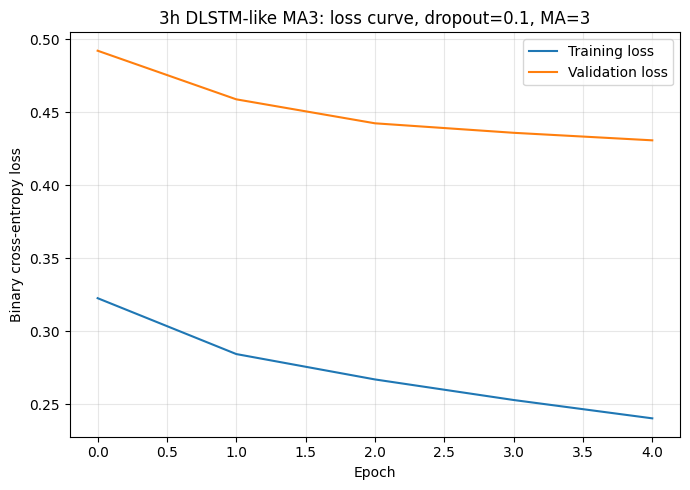

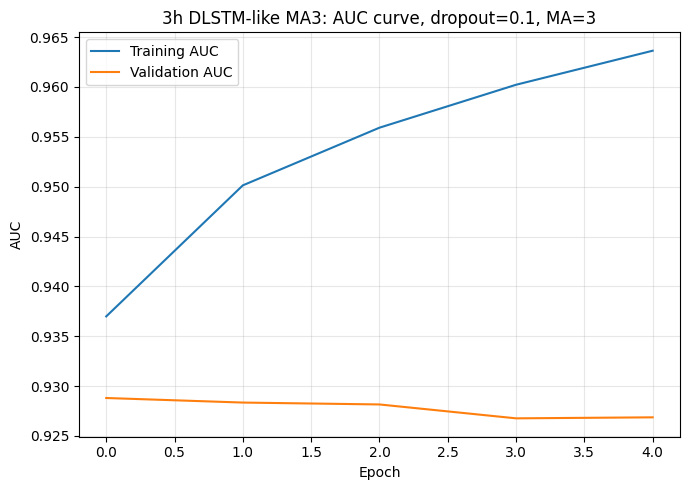

{'Dropout': 0.1, 'Val_TSS_Selected': np.float64(0.7121), 'TSS': np.float64(0.7073), 'HSS': np.float64(0.0497), 'ROC_AUC': np.float64(0.9317), 'PR_AUC': np.float64(0.1592), 'Recall': 0.8431, 'Precision': 0.0306, 'F1': 0.059, 'Best_Val_AUC': 0.9288, 'AUC_Gap_Train_Minus_Val': 0.0082, 'Loss_Gap_Val_Minus_Train': 0.1695, 'Best_Epoch_By_Val_AUC': 1}

3h dropout sensitivity: DLSTM-like MA3, dropout=0.2
Epoch 1/15
552/552 ━━━━━━━━━━━━━━━━━━━━ 21s 34ms/step - auc: 0.9348 - loss: 0.3268 - val_auc: 0.9273 - val_loss: 0.4799
Epoch 2/15
552/552 ━━━━━━━━━━━━━━━━━━━━ 18s 33ms/step - auc: 0.9499 - loss: 0.2855 - val_auc: 0.9265 - val_loss: 0.4397
Epoch 3/15
552/552 ━━━━━━━━━━━━━━━━━━━━ 21s 37ms/step - auc: 0.9553 - loss: 0.2685 - val_auc: 0.9263 - val_loss: 0.4405
Epoch 4/15
552/552 ━━━━━━━━━━━━━━━━━━━━ 20s 36ms/step - auc: 0.9588 - loss: 0.2570 - val_auc: 0.9238 - val_loss: 0.4430
Epoch 5/15
552/552 ━━━━━━━━━━━━━━━━━━━━ 20s 36ms/step - auc: 0.9616 - loss: 0.2472 - val_auc: 0.9244 - val_loss: 0.4030


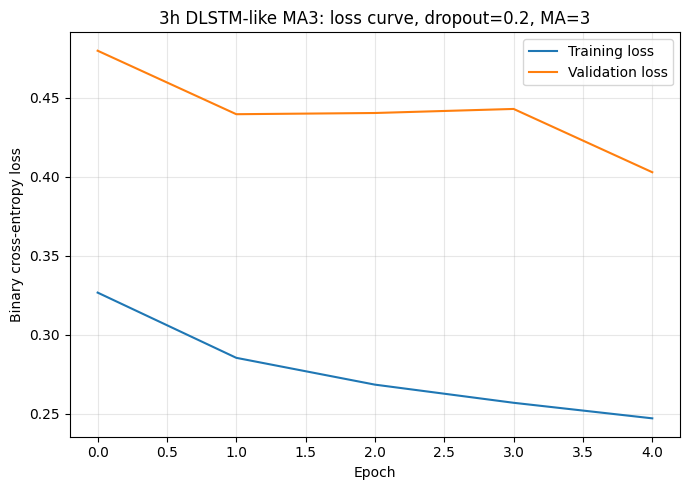

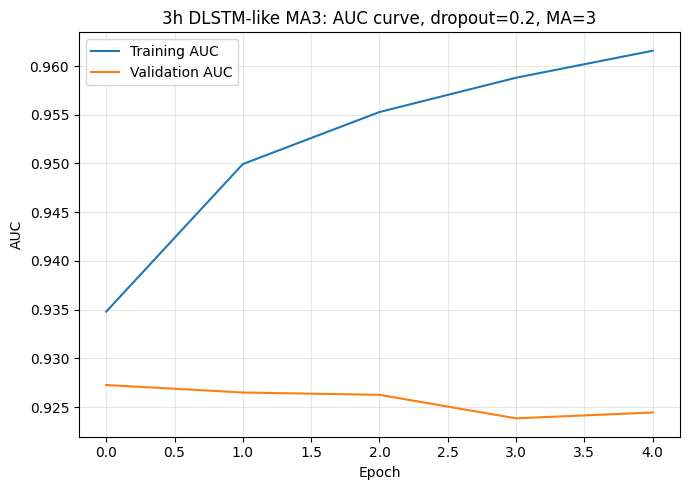

{'Dropout': 0.2, 'Val_TSS_Selected': np.float64(0.6957), 'TSS': np.float64(0.716), 'HSS': np.float64(0.0478), 'ROC_AUC': np.float64(0.9347), 'PR_AUC': np.float64(0.1697), 'Recall': 0.8595, 'Precision': 0.0296, 'F1': 0.0571, 'Best_Val_AUC': 0.9273, 'AUC_Gap_Train_Minus_Val': 0.0075, 'Loss_Gap_Val_Minus_Train': 0.1531, 'Best_Epoch_By_Val_AUC': 1}

3h dropout sensitivity: DLSTM-like MA3, dropout=0.3
Epoch 1/15
552/552 ━━━━━━━━━━━━━━━━━━━━ 23s 36ms/step - auc: 0.9346 - loss: 0.3274 - val_auc: 0.9298 - val_loss: 0.4560
Epoch 2/15
552/552 ━━━━━━━━━━━━━━━━━━━━ 21s 38ms/step - auc: 0.9500 - loss: 0.2852 - val_auc: 0.9273 - val_loss: 0.4277
Epoch 3/15
552/552 ━━━━━━━━━━━━━━━━━━━━ 21s 38ms/step - auc: 0.9543 - loss: 0.2716 - val_auc: 0.9291 - val_loss: 0.4404
Epoch 4/15
552/552 ━━━━━━━━━━━━━━━━━━━━ 21s 38ms/step - auc: 0.9577 - loss: 0.2603 - val_auc: 0.9268 - val_loss: 0.4146
Epoch 5/15
552/552 ━━━━━━━━━━━━━━━━━━━━ 22s 39ms/step - auc: 0.9594 - loss: 0.2543 - val_auc: 0.9245 - val_loss: 0.4300


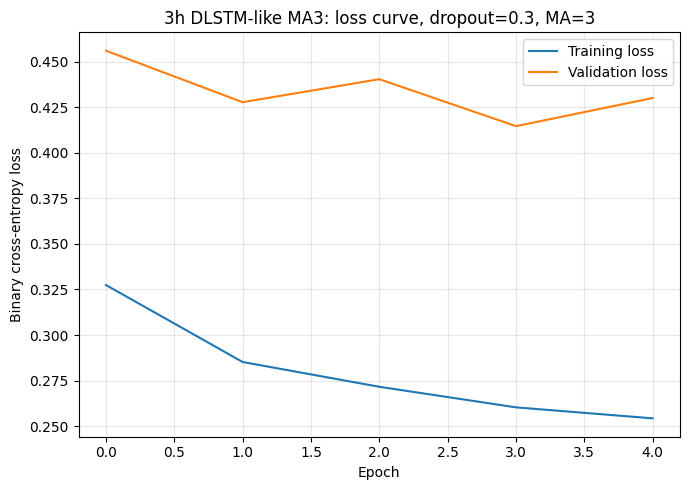

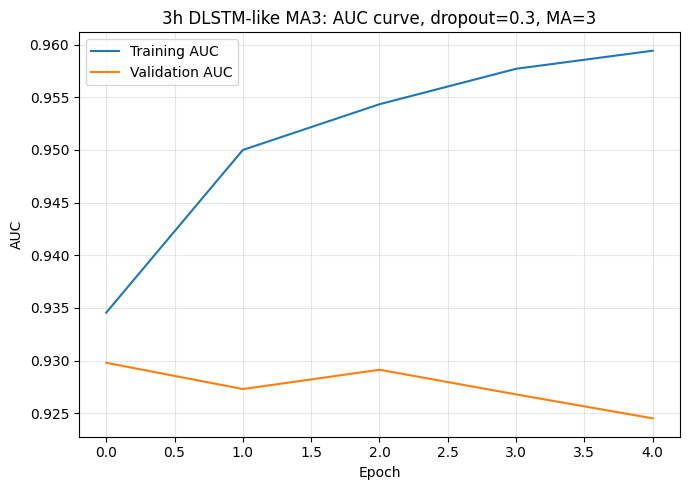

{'Dropout': 0.3, 'Val_TSS_Selected': np.float64(0.7106), 'TSS': np.float64(0.7008), 'HSS': np.float64(0.0443), 'ROC_AUC': np.float64(0.9322), 'PR_AUC': np.float64(0.1782), 'Recall': 0.8529, 'Precision': 0.0277, 'F1': 0.0537, 'Best_Val_AUC': 0.9298, 'AUC_Gap_Train_Minus_Val': 0.0048, 'Loss_Gap_Val_Minus_Train': 0.1285, 'Best_Epoch_By_Val_AUC': 1}

3h dropout sensitivity: DLSTM-like MA3, dropout=0.5
Epoch 1/15
552/552 ━━━━━━━━━━━━━━━━━━━━ 24s 40ms/step - auc: 0.9317 - loss: 0.3347 - val_auc: 0.9277 - val_loss: 0.4714
Epoch 2/15
552/552 ━━━━━━━━━━━━━━━━━━━━ 20s 36ms/step - auc: 0.9463 - loss: 0.2957 - val_auc: 0.9287 - val_loss: 0.4589
Epoch 3/15
552/552 ━━━━━━━━━━━━━━━━━━━━ 20s 36ms/step - auc: 0.9503 - loss: 0.2840 - val_auc: 0.9283 - val_loss: 0.4745
Epoch 4/15
552/552 ━━━━━━━━━━━━━━━━━━━━ 21s 38ms/step - auc: 0.9544 - loss: 0.2707 - val_auc: 0.9282 - val_loss: 0.4381
Epoch 5/15
552/552 ━━━━━━━━━━━━━━━━━━━━ 20s 35ms/step - auc: 0.9560 - loss: 0.2659 - val_auc: 0.9265 - val_loss: 0.4456

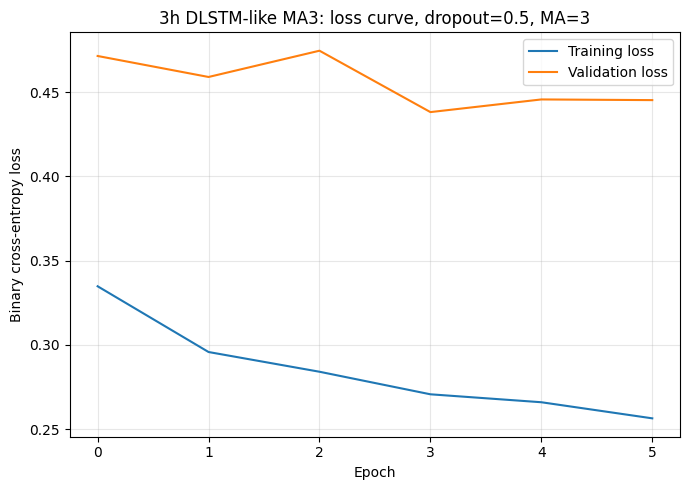

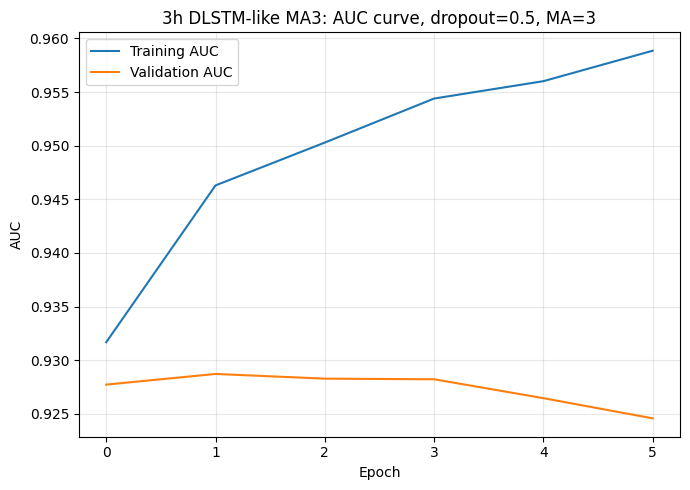

{'Dropout': 0.5, 'Val_TSS_Selected': np.float64(0.7115), 'TSS': np.float64(0.7347), 'HSS': np.float64(0.0573), 'ROC_AUC': np.float64(0.9352), 'PR_AUC': np.float64(0.185), 'Recall': 0.8562, 'Precision': 0.0346, 'F1': 0.0665, 'Best_Val_AUC': 0.9287, 'AUC_Gap_Train_Minus_Val': 0.0176, 'Loss_Gap_Val_Minus_Train': 0.1632, 'Best_Epoch_By_Val_AUC': 2}


,Horizon,Model,Model_Type,MA_Kernel,Dropout,Threshold,Val_TSS_Selected,TSS,HSS,ROC_AUC,...,Epochs_Run,Train_N,Val_N,Test_N,Train_Pos,Val_Pos,Test_Pos,Learning_Curve_CSV,Loss_Curve_PNG,AUC_Curve_PNG
0,3h,DLSTM-like MA3,dlstm,3,0.1,0.54,0.712142,0.707265,0.049749,0.931652,...,5,282307,60494,60495,1418,849,306,/content/drive/MyDrive/ASR_MAJOR_REVISION_OVER...,/content/drive/MyDrive/ASR_MAJOR_REVISION_OVER...,/content/drive/MyDrive/ASR_MAJOR_REVISION_OVER...
1,3h,DLSTM-like MA3,dlstm,3,0.2,0.50,0.695694,0.715979,0.047824,0.934679,...,5,282307,60494,60495,1418,849,306,/content/drive/MyDrive/ASR_MAJOR_REVISION_OVER...,/content/drive/MyDrive/ASR_MAJOR_REVISION_OVER...,/content/drive/MyDrive/ASR_MAJOR_REVISION_OVER...
2,3h,DLSTM-like MA3,dlstm,3,0.3,0.43,0.710588,0.700787,0.044312,0.932203,...,5,282307,60494,60495,1418,849,306,/content/drive/MyDrive/ASR_MAJOR_REVISION_OVER...,/content/drive/MyDrive/ASR_MAJOR_REVISION_OVER...,/content/drive/MyDrive/ASR_MAJOR_REVISION_OVER...
3,3h,DLSTM-like MA3,dlstm,3,0.5,0.54,0.711496,0.734659,0.057297,0.935168,...,6,282307,60494,60495,1418,849,306,/content/drive/MyDrive/ASR_MAJOR_REVISION_OVER...,/content/drive/MyDrive/ASR_MAJOR_REVISION_OVER...,/content/drive/MyDrive/ASR_MAJOR_REVISION_OVER...



Saved dropout sensitivity results to: /content/drive/MyDrive/ASR_MAJOR_REVISION_OVERFITTING/dropout_sensitivity/dropout_sensitivity_3h.csv


In [41]:
# ============================================================
# ROUND 3C: 3H OVERFITTING + DROPOUT SENSITIVITY
# Representative model: DLSTM-like with MA3
# Paste inside 3h notebook AFTER X_all, y_all, time_all exist
# ============================================================

assert "X_all" in globals(), "X_all not found. Run the 3h sequence rebuild cell first."
assert "y_all" in globals(), "y_all not found. Run the 3h sequence rebuild cell first."
assert "time_all" in globals(), "time_all not found. Run the 3h sequence rebuild cell first."

assert X_all.shape[1] == 8, f"Expected 3h sequence length 8, got {X_all.shape[1]}"
assert X_all.shape[-1] == 21, f"Expected 3h 21 features, got {X_all.shape[-1]}"

dropout_3h_df = run_dropout_sensitivity(
    X_full=X_all,
    y_full=y_all,
    time_full=time_all,
    horizon="3h",
    model_type="dlstm",
    dropout_values=[0.1, 0.2, 0.3, 0.5],
    ma_kernel=3,
    epochs=15,
    batch_size=512,
    patience=4,
    lr=1e-3,
    units=64,
    dense_units=32,
)